### Cell 1: Purpose, Formula, and Logic
- **Role**: Documentation and pipeline structuring.
- **Algorithm Logic**: Defines section intent, execution context, and reading order for the next implementation blocks.
- **Formula**: No numerical formula in this cell; this step defines structure and scope for subsequent computations.


# Pipeline New (7036)

Build a new executable Pipeline Notebook in the `7036` root directory, containing:
1. Path definition and target Notebook management (including backup)
2. Basic configuration driven by parameter unit
3. Migrate key steps and insert new logic (sentiment + rolling decay + backtest)
4. Path/date/switch parameterization
5. Pre-run inspection
6. End-to-end running check (nbclient)
7. Generate running inspection report and re-run entry

### Cell 2: Purpose, Formula, and Logic
- **Role**: Documentation and pipeline structuring.
- **Algorithm Logic**: Defines section intent, execution context, and reading order for the next implementation blocks.
- **Formula**: No numerical formula in this cell; this step defines structure and scope for subsequent computations.


# Sentiment Factor


### Cell 3: Purpose, Formula, and Logic
- **Role**: Compute step: # DuckDB content visualization (table list/field/sample/date coverage)
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $R=\sigma_{\text{filters}}(A\ \Join\ B)$ then aggregate by date/stock as required.


In [18]:
# DuckDB content visualization (table list/field/sample/date overlay)
from pathlib import Path
import duckdb
import pandas as pd
from IPython.display import display

db_candidates = [
    Path("../trading_data.duckdb"),
    Path("trading_data.duckdb"),
    Path.cwd() / "trading_data.duckdb",
]
db_path = next((p.resolve() for p in db_candidates if p.exists()), db_candidates[0].resolve())

print(f"Using DuckDB: {db_path}")
con = duckdb.connect(str(db_path), read_only=True)

try:
    tables_df = con.execute("SHOW TABLES").fetchdf()
    print("\n=== Tables ===")
    display(tables_df)

    if tables_df.empty:
        raise ValueError("DuckDB 中没有可用表")

    focus_table = "trading_data_clean" if "trading_data_clean" in tables_df.iloc[:, 0].tolist() else tables_df.iloc[0, 0]
    print(f"\n=== Focus Table: {focus_table} ===")

    schema_df = con.execute(f"PRAGMA table_info('{focus_table}')").fetchdf()
    print("\n[Schema]")
    display(schema_df)

    summary_df = con.execute(
        f"""
        SELECT
            COUNT(*) AS total_rows,
            COUNT(DISTINCT stock_code) AS stock_count,
            MIN(trade_date) AS min_trade_date,
            MAX(trade_date) AS max_trade_date
        FROM {focus_table}
        """
    ).fetchdf()
    print("\n[Coverage Summary]")
    display(summary_df)

    sample_df = con.execute(
        f"""
        SELECT trade_date, stock_code, stock_name, close, prev_close, change_pct
        FROM {focus_table}
        WHERE trade_date IS NOT NULL
        ORDER BY trade_date DESC, stock_code
        LIMIT 20
        """
    ).fetchdf()
    print("\n[Latest 20 Rows]")
    display(sample_df)

    hs300_df = con.execute(
        f"""
        SELECT trade_date, stock_code, close, prev_close, change_pct
        FROM {focus_table}
        WHERE LPAD(REGEXP_EXTRACT(COALESCE(stock_code, ''), '([0-9]+)', 1), 6, '0') = '000300'
        ORDER BY trade_date DESC
        LIMIT 20
        """
    ).fetchdf()
    print("\n[HS300 (000300) Latest 20 Rows]")
    display(hs300_df)
finally:
    con.close()

Using DuckDB: D:\MFIN\7036\trading_data.duckdb

=== Tables ===


,name
0,trading_data_clean
1,trading_data_en
2,trading_data_raw



=== Focus Table: trading_data_clean ===

[Schema]


,cid,name,type,notnull,dflt_value,pk
0,0,source_file,VARCHAR,False,None,False
1,1,stock_code,VARCHAR,False,None,False
2,2,stock_name,VARCHAR,False,None,False
3,3,industry,VARCHAR,False,None,False
4,4,region,VARCHAR,False,None,False
5,5,ts_code,VARCHAR,False,None,False
6,6,list_date,DATE,False,None,False
7,7,trade_date,DATE,False,None,False
8,8,open,DOUBLE,False,None,False
9,9,high,DOUBLE,False,None,False



[Coverage Summary]


,total_rows,stock_count,min_trade_date,max_trade_date
0,15800649,5739,1993-01-07,2025-12-05



[Latest 20 Rows]


,trade_date,stock_code,stock_name,close,prev_close,change_pct
0,2025-12-05,000001.SH,None,3902.8076,3875.7933,0.7000
1,2025-12-05,000016.SH,None,3002.0087,2974.3371,0.9300
2,2025-12-05,000300.SH,None,4584.5368,4546.5664,0.8400
3,2025-12-05,000905.SH,None,7097.8389,7012.8061,1.2100
4,2025-12-05,1,平安银行,11.5300,11.4900,0.3481
5,2025-12-05,10,美丽生态,3.7300,3.7400,-0.2674
6,2025-12-05,100,TCL科技,4.5500,4.3600,4.3578
7,2025-12-05,11,深物业A,9.4300,9.3500,0.8556
8,2025-12-05,12,南玻A,4.7300,4.7100,0.4246
9,2025-12-05,1201,东瑞股份,14.9600,14.9200,0.2681



[HS300 (000300) Latest 20 Rows]


,trade_date,stock_code,close,prev_close,change_pct
0,2025-12-05,000300.SH,4584.5368,4546.5664,0.84
1,2025-12-04,000300.SH,4546.5664,4531.0486,0.34
2,2025-12-03,000300.SH,4531.0486,4554.3347,-0.51
3,2025-12-02,000300.SH,4554.3347,4576.4856,-0.48
4,2025-12-01,000300.SH,4576.4856,4526.6616,1.10
5,2025-11-28,000300.SH,4526.6616,4515.4027,0.25
6,2025-11-27,000300.SH,4515.4027,4517.6255,-0.05
7,2025-11-26,000300.SH,4517.6255,4490.4047,0.61
8,2025-11-25,000300.SH,4490.4047,4448.0478,0.95
9,2025-11-24,000300.SH,4448.0478,4453.6076,-0.12


### Cell 4: Purpose, Formula, and Logic
- **Role**: Compute step: from generate_labels import LabelGenerator
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $R=\sigma_{\text{filters}}(A\ \Join\ B)$ then aggregate by date/stock as required.


GENERATING LABELS FOR STOCK PERFORMANCE

[1/5] Loading stock list...
✓ Loaded 300 stocks

[2/5] Loading and aggregating trading data...
✓ Aggregated returns shape: (8000, 302)

[3/5] Calculating forward t~t+90 cumulative excess returns...
Saved forward 90d excess returns to forward_90d_excess_returns.csv
✓ Forward 90D excess returns shape: (8000, 301)

[4/5] Generating labels...
  → Generating 3-class labels...
  → Generating regression labels...
✓ Required labels generated successfully

[5/5] Displaying results and saving...


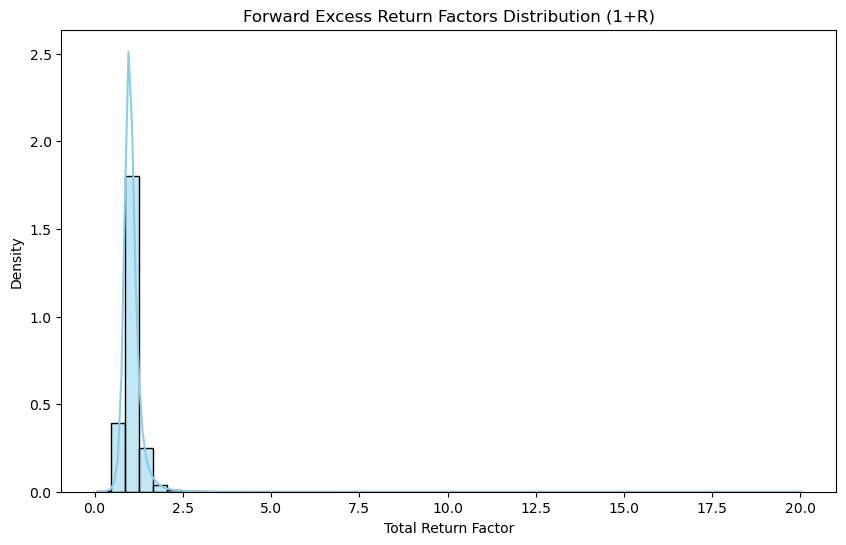

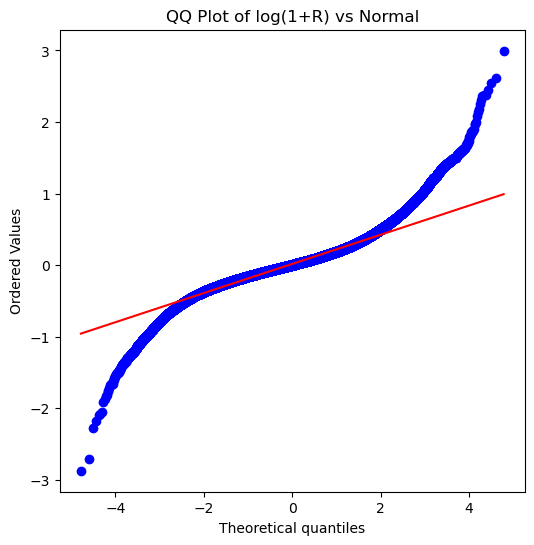


LABEL STATISTICS

📊 3-CLASS LABELS DISTRIBUTION:
------------------------------------------------------------

Label Distribution (3-class):
1.0    36.25
2.0    31.88
0.0    31.88
Name: proportion, dtype: float64

📊 REGRESSION LABELS STATISTICS:
------------------------------------------------------------
count    752754.000000
mean          0.043774
std           0.246170
min          -0.772328
25%          -0.095188
50%           0.006030
75%           0.129699
max          14.577989
dtype: float64

📌 EXTREME VALUE THRESHOLDS:
------------------------------------------------------------
1% quantile : -0.356432
99% quantile: 0.910921

🔻 BOTTOM 10 EXTREME VALUES:
------------------------------------------------------------
    交易日期  stock  excess_return
20140822 002594      -0.772328
20140902 002594      -0.761762
20140901 002594      -0.761117
20140815 002594      -0.758888
20140808 002594      -0.756990
20140820 002594      -0.745524
20140819 002594      -0.740186
20140821 002594   

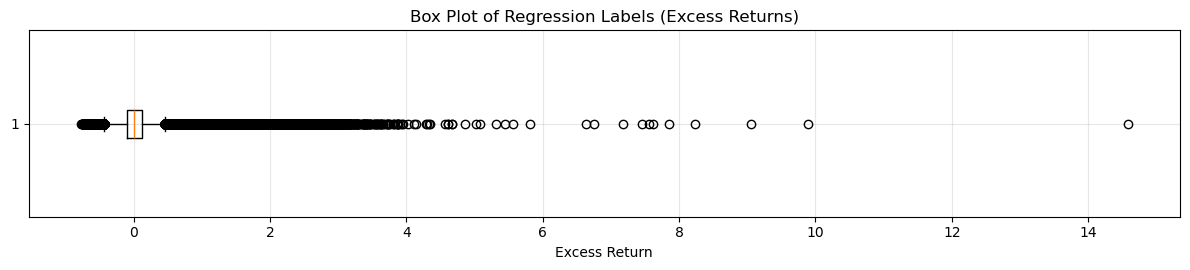


SAVING LABELS
Saved 3-class labels to ./labels_3class.csv
Saved regression labels to ./labels_regression.csv


In [20]:
from generate_labels import LabelGenerator
import pandas as pd
import os
import matplotlib.pyplot as plt

# Initialize label generator
print("="*60)
print("GENERATING LABELS FOR STOCK PERFORMANCE")
print("="*60)

gen = LabelGenerator(stock_list_path="HS300.csv")

# Step 1: Load stock list
print("\n[1/5] Loading stock list...")
gen.load_stock_list()
print(f"✓ Loaded {len(gen.stock_list)} stocks")

# Step 2: Load and aggregate returns
print("\n[2/5] Loading and aggregating trading data...")
all_returns = gen.load_and_aggregate_returns(duckdb_path="../trading_data.duckdb")
print(f"✓ Aggregated returns shape: {all_returns.shape}")

# Step 3: Calculate forward t~t+90 cumulative excess returns
print("\n[3/5] Calculating forward t~t+90 cumulative excess returns...")
forward_excess_90d = gen.calculate_excess_returns(horizon_days=90)
print(f"✓ Forward 90D excess returns shape: {forward_excess_90d.shape}")

# Step 4: Generate required labels only (3-class + regression)
print("\n[4/5] Generating labels...")
print("  → Generating 3-class labels...")
labels_3class = gen.generate_3class_labels(forward_excess_90d)
print("  → Generating regression labels...")
labels_regression = gen.generate_regression_labels(forward_excess_90d)
print("✓ Required labels generated successfully")

# Step 5: Display statistics and save
print("\n[5/5] Displaying results and saving...")
gen.plot_return_distribution(forward_excess_90d)

print("\n" + "="*60)
print("LABEL STATISTICS")
print("="*60)

print("\n📊 3-CLASS LABELS DISTRIBUTION:")
print("-"*60)
gen.get_label_statistics(labels_3class, "3-class")

print("\n📊 REGRESSION LABELS STATISTICS:")
print("-"*60)
reg_series = labels_regression.drop(columns=['交易日期']).stack(dropna=True)
print(reg_series.describe())

# === Added: extreme values + box plot ===
reg_long = (
    labels_regression
    .set_index('交易日期')
    .stack(dropna=True)
    .rename('excess_return')
    .reset_index()
    .rename(columns={'level_1': 'stock'})
)
reg_long['excess_return'] = pd.to_numeric(reg_long['excess_return'], errors='coerce')
reg_long = reg_long.dropna(subset=['excess_return'])

if not reg_long.empty:
    q01 = reg_long['excess_return'].quantile(0.01)
    q99 = reg_long['excess_return'].quantile(0.99)
    print("\n📌 EXTREME VALUE THRESHOLDS:")
    print("-"*60)
    print(f"1% quantile : {q01:.6f}")
    print(f"99% quantile: {q99:.6f}")

    print("\n🔻 BOTTOM 10 EXTREME VALUES:")
    print("-"*60)
    print(reg_long.nsmallest(10, 'excess_return').to_string(index=False))

    print("\n🔺 TOP 10 EXTREME VALUES:")
    print("-"*60)
    print(reg_long.nlargest(10, 'excess_return').to_string(index=False))

    plt.figure(figsize=(12, 2.8))
    plt.boxplot(reg_long['excess_return'], vert=False, showfliers=True)
    plt.title('Box Plot of Regression Labels (Excess Returns)')
    plt.xlabel('Excess Return')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠ No valid regression values for extreme-value analysis and box plot.")

print("\n" + "="*60)
print("SAVING LABELS")
print("="*60)

gen.save_labels(
    labels_3class=labels_3class,
    labels_regression=labels_regression,
    output_dir="."
)

### Cell 5: Purpose, Formula, and Logic
- **Role**: Compute step: # Verify saved files
- **Algorithm Logic**: Loads and aligns datasets by keys/date, then prepares a clean analysis panel for subsequent computation.
- **Formula**: $y=f(x)$ with deterministic transformation steps encoded in this cell.


In [21]:
# Verify saved files
print("\n✓ Verification:")
for filename in ["labels_3class.csv", "labels_regression.csv"]:
    if os.path.exists(filename):
        size = os.path.getsize(filename)
        rows = len(pd.read_csv(filename))
        print(f"  ✓ {filename} ({size/1024:.2f} KB, {rows} rows)")
    else:
        print(f"  ✗ {filename} not found")

print("\n" + "="*60)
print("✅ LABEL GENERATION COMPLETE")
print("="*60)


✓ Verification:
  ✓ labels_3class.csv (4714.65 KB, 8000 rows)
  ✓ labels_regression.csv (16687.04 KB, 8000 rows)

✅ LABEL GENERATION COMPLETE


### Cell 6: Purpose, Formula, and Logic
- **Role**: Compute step: import os
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $y=f(x)$ with deterministic transformation steps encoded in this cell.


In [22]:
import os
import importlib
import generate_dataset as gd

# Force loading of the latest version to avoid getting old cached code in the notebook
importlib.reload(gd)
generate_all_datasets = gd.generate_all_datasets

print("=" * 60)
print("GENERATING DAILY DATASETS FOR MODEL TRAINING")
print("=" * 60)

datasets = generate_all_datasets(
    labels_3class="labels_3class.csv",
    labels_regression="labels_regression.csv",
    mapping_file="HS300.csv",
    reports_dir="md_summary_en_512_split_copy",
    cutoff_date="2020-12-31",
    val_ratio=0.2,
)

required_keys = [
    "train_3class_df",
    "val_3class_df",
    "backtest_3class_df",
    "train_regression_df",
    "val_regression_df",
    "backtest_regression_df",
]
missing_keys = [k for k in required_keys if k not in datasets]
if missing_keys:
    raise KeyError(f"Missing keys in datasets: {missing_keys}")

print("\n" + "=" * 60)
print("✅ DAILY DATASET GENERATION COMPLETE")
print("=" * 60)
print("\nGenerated Files:")
print("  - train_3class.csv, val_3class.csv, backtest_3class.csv")
print("  - train_regression.csv, val_regression.csv, backtest_regression.csv")

print("\n" + "=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

stats = {
    "train_3class.csv": len(datasets["train_3class_df"]),
    "val_3class.csv": len(datasets["val_3class_df"]),
    "backtest_3class.csv": len(datasets["backtest_3class_df"]),
    "train_regression.csv": len(datasets["train_regression_df"]),
    "val_regression.csv": len(datasets["val_regression_df"]),
    "backtest_regression.csv": len(datasets["backtest_regression_df"]),
}

# Extra check: prevent full empty
if sum(stats.values()) == 0:
    raise ValueError("All generated splits are empty. Please check daily labels/report matching.")

GENERATING DAILY DATASETS FOR MODEL TRAINING

=== Generating 3-class Dataset ===
✓ Generated 3-class dataset: train (9064), val (2267), backtest (19614)

=== Generating Regression Dataset ===
✓ Generated regression dataset: train (9064), val (2267), backtest (19614)

✅ DAILY DATASET GENERATION COMPLETE

Generated Files:
  - train_3class.csv, val_3class.csv, backtest_3class.csv
  - train_regression.csv, val_regression.csv, backtest_regression.csv

DATASET STATISTICS


### Cell 7: Purpose, Formula, and Logic
- **Role**: Compute step: from pathlib import Path
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $\text{tokens}=\mathrm{Tokenizer}(text)$ and chunking follows fixed length $L$ with overlap $o$.


In [26]:
from pathlib import Path
import inspect
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset

# Key compatibility patch: The current environment datasets->pyarrow DLL is abnormal. Disable datasets detection first and then import it into Trainer.
import transformers.utils.import_utils as hf_import_utils
hf_import_utils._datasets_available = False

from transformers import (
    BertTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

print("=" * 88)
print("4.1b FINBERT FINE-TUNE (OPTIMIZED: 3CLASS + REGRESSION, ROBUST TRAINING)")
print("=" * 88)

# ===== Data files (from 3.2)
train_3 = Path("train_3class_daily.csv")
val_3 = Path("val_3class_daily.csv")
train_reg = Path("train_regression_daily.csv")
val_reg = Path("val_regression_daily.csv")

for fp in [train_3, val_3, train_reg, val_reg]:
    if not fp.exists():
        raise FileNotFoundError(f"Required dataset not found: {fp}")

# ===== Training configuration (classification/regression separation)
SEED = 42
BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
MAX_LENGTH = 512
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 1.0
FREEZE_LOWER_LAYERS = 4  # 冻结底层减少过拟合，可按需改为 0
FORCE_RETRAIN = False
MODEL_NAME = "ProsusAI/finbert"

# Classification task hyperparameters (robust, suppressing overfitting)
CLS_LEARNING_RATE = 1.0e-5
CLS_WEIGHT_DECAY = 0.10
CLS_NUM_EPOCHS = 8
CLS_LABEL_SMOOTHING = 0.06
EARLY_STOPPING_PATIENCE_CLS = 1

# Regression task hyperparameters (more robust)
REG_LEARNING_RATE = 9.0e-6
REG_WEIGHT_DECAY = 0.08
REG_NUM_EPOCHS = 6
EARLY_STOPPING_PATIENCE_REG = 1

# Return label cropping
REG_CLIP_Q_LOW = 0.01
REG_CLIP_Q_HIGH = 0.99

# Regression extra regularization (penalize + regularization)
REG_SIGN_PENALTY = 0.05
REG_PRED_L2_PENALTY = 2e-4

model_3_dir = Path("finbert_finetuned_3class_model")
model_reg_dir = Path("finbert_finetuned_regression_model")

# ===== Fixed random seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def _safe_text_series(s: pd.Series) -> pd.Series:
    return s.astype(str).fillna("").str.strip()


def _count_trainable_params(model) -> tuple[int, int]:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def freeze_bert_bottom_layers(model, n_layers: int = 0):
    if n_layers <= 0:
        return
    if not hasattr(model, "bert"):
        return

    for p in model.bert.embeddings.parameters():
        p.requires_grad = False

    for layer in model.bert.encoder.layer[:n_layers]:
        for p in layer.parameters():
            p.requires_grad = False


class TextLabelDataset(Dataset):
    def __init__(self, texts: list[str], labels: list[float], tokenizer, max_length=512, is_regression=False):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.is_regression = is_regression

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding=False,
            max_length=self.max_length,
        )
        if self.is_regression:
            enc["labels"] = float(self.labels[idx])
        else:
            enc["labels"] = int(self.labels[idx])
        return enc


class WeightedCETrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor | None = None, label_smoothing: float = 0.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.label_smoothing = float(label_smoothing)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        weight = None
        if self.class_weights is not None:
            weight = self.class_weights.to(logits.device)

        loss_fct = nn.CrossEntropyLoss(weight=weight, label_smoothing=self.label_smoothing)
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


class HuberRegressionTrainer(Trainer):
    def __init__(self, sign_penalty: float = 0.0, pred_l2_penalty: float = 0.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.sign_penalty = float(sign_penalty)
        self.pred_l2_penalty = float(pred_l2_penalty)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits").squeeze(-1)

        # base loss: more robust to extreme values
        base_loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)

        # penalize: Penalize when the prediction is opposite to the true sign
        sign_pen = torch.relu(-(logits * labels)).mean()

        # Regularization: Constrain the prediction amplitude to prevent excessive output
        pred_l2 = (logits ** 2).mean()

        loss = base_loss + self.sign_penalty * sign_pen + self.pred_l2_penalty * pred_l2
        return (loss, outputs) if return_outputs else loss


def macro_f1_from_int_arrays(y_true: np.ndarray, y_pred: np.ndarray, num_labels: int) -> float:
    f1_list = []
    for cls in range(num_labels):
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        f1_list.append(f1)

    return float(np.mean(f1_list)) if f1_list else 0.0


def compute_metrics_3class(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    labels = labels.astype(int)

    acc = float((preds == labels).mean()) if len(labels) > 0 else 0.0
    macro_f1 = macro_f1_from_int_arrays(labels, preds, num_labels=3)
    return {"accuracy": acc, "macro_f1": macro_f1}


def compute_metrics_reg(eval_pred):
    logits, labels = eval_pred
    preds = np.squeeze(logits)
    labels = np.squeeze(labels)

    mse = float(np.mean((preds - labels) ** 2)) if len(labels) > 0 else np.nan
    rmse = float(np.sqrt(mse)) if np.isfinite(mse) else np.nan
    mae = float(np.mean(np.abs(preds - labels))) if len(labels) > 0 else np.nan

    # Direction accuracy: the ratio of predicted and true signs
    sign_acc = float(np.mean(np.sign(preds) == np.sign(labels))) if len(labels) > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "sign_acc": sign_acc}


def prepare_classification_data(train_file: Path, val_file: Path):
    train_df = pd.read_csv(train_file)
    val_df = pd.read_csv(val_file)

    required = {"text", "label"}
    if not required.issubset(train_df.columns) or not required.issubset(val_df.columns):
        raise ValueError(f"Missing required columns in classification dataset. Need: {required}")

    train_df = train_df[["text", "label"]].copy()
    val_df = val_df[["text", "label"]].copy()

    train_df["text"] = _safe_text_series(train_df["text"])
    val_df["text"] = _safe_text_series(val_df["text"])

    train_df["label"] = pd.to_numeric(train_df["label"], errors="coerce")
    val_df["label"] = pd.to_numeric(val_df["label"], errors="coerce")

    train_df = train_df.dropna(subset=["label"])
    val_df = val_df.dropna(subset=["label"])

    train_df["label"] = train_df["label"].astype(int)
    val_df["label"] = val_df["label"].astype(int)

    train_df = train_df[train_df["label"].isin([0, 1, 2])]
    val_df = val_df[val_df["label"].isin([0, 1, 2])]

    if train_df.empty or val_df.empty:
        raise ValueError("Classification train/val is empty after cleaning.")

    print("\n[3CLASS] data cleaned:")
    print(f"  train rows={len(train_df):,}, val rows={len(val_df):,}")
    print("  train label distribution:")
    print(train_df["label"].value_counts().sort_index().to_string())
    print("  val label distribution:")
    print(val_df["label"].value_counts().sort_index().to_string())

    # Category weight (inverse frequency)
    counts = train_df["label"].value_counts().reindex([0, 1, 2], fill_value=0).values.astype(float)
    weights = np.where(counts > 0, counts.sum() / (len(counts) * counts), 0.0)
    class_weights = torch.tensor(weights, dtype=torch.float32)

    print(f"  class weights: {class_weights.tolist()}")
    return train_df, val_df, class_weights


def prepare_regression_data(train_file: Path, val_file: Path):
    train_df = pd.read_csv(train_file)
    val_df = pd.read_csv(val_file)

    required = {"text", "label"}
    if not required.issubset(train_df.columns) or not required.issubset(val_df.columns):
        raise ValueError(f"Missing required columns in regression dataset. Need: {required}")

    train_df = train_df[["text", "label"]].copy()
    val_df = val_df[["text", "label"]].copy()

    train_df["text"] = _safe_text_series(train_df["text"])
    val_df["text"] = _safe_text_series(val_df["text"])

    train_df["label"] = pd.to_numeric(train_df["label"], errors="coerce")
    val_df["label"] = pd.to_numeric(val_df["label"], errors="coerce")

    train_df = train_df.dropna(subset=["label"])
    val_df = val_df.dropna(subset=["label"])

    if train_df.empty or val_df.empty:
        raise ValueError("Regression train/val is empty after cleaning.")

    # Regression label extreme value clipping (by train quantiles)
    q_low = float(train_df["label"].quantile(REG_CLIP_Q_LOW))
    q_high = float(train_df["label"].quantile(REG_CLIP_Q_HIGH))
    train_df["label"] = train_df["label"].clip(q_low, q_high)
    val_df["label"] = val_df["label"].clip(q_low, q_high)

    print("\n[REG] data cleaned + clipped:")
    print(f"  train rows={len(train_df):,}, val rows={len(val_df):,}")
    print(f"  clip range: [{q_low:.6f}, {q_high:.6f}]")
    print("  train label describe:")
    print(train_df["label"].describe().to_string())

    return train_df, val_df


def build_training_args(
    output_dir: Path,
    metric_name: str,
    greater_is_better: bool,
    learning_rate: float,
    weight_decay: float,
    num_train_epochs: int,
):
    sig = inspect.signature(TrainingArguments.__init__)
    strategy_key = "evaluation_strategy" if "evaluation_strategy" in sig.parameters else "eval_strategy"

    kwargs = dict(
        output_dir=str(output_dir),
        overwrite_output_dir=True,
        do_train=True,
        do_eval=True,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model=metric_name,
        greater_is_better=greater_is_better,
        save_total_limit=2,
        learning_rate=learning_rate,
        lr_scheduler_type="cosine",
        warmup_ratio=WARMUP_RATIO,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        max_grad_norm=MAX_GRAD_NORM,
        logging_dir=str(output_dir / "logs"),
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        seed=SEED,
        report_to=[],
    )
    kwargs[strategy_key] = "epoch"
    return TrainingArguments(**kwargs)


def run_finetune_3class(train_file: Path, val_file: Path, output_dir: Path):
    train_df, val_df, class_weights = prepare_classification_data(train_file, val_file)

    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        ignore_mismatched_sizes=True,
    )

    freeze_bert_bottom_layers(model, FREEZE_LOWER_LAYERS)
    trainable, total = _count_trainable_params(model)
    print(f"[3CLASS] trainable params: {trainable:,} / {total:,}")
    print(f"[3CLASS] hparams: lr={CLS_LEARNING_RATE}, wd={CLS_WEIGHT_DECAY}, epochs={CLS_NUM_EPOCHS}, label_smoothing={CLS_LABEL_SMOOTHING}, patience={EARLY_STOPPING_PATIENCE_CLS}")

    train_ds = TextLabelDataset(
        texts=train_df["text"].tolist(),
        labels=train_df["label"].tolist(),
        tokenizer=tokenizer,
        max_length=MAX_LENGTH,
        is_regression=False,
    )
    val_ds = TextLabelDataset(
        texts=val_df["text"].tolist(),
        labels=val_df["label"].tolist(),
        tokenizer=tokenizer,
        max_length=MAX_LENGTH,
        is_regression=False,
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
        pad_to_multiple_of=8 if torch.cuda.is_available() else None,
    )

    train_args = build_training_args(
        output_dir=output_dir,
        metric_name="eval_macro_f1",
        greater_is_better=True,
        learning_rate=CLS_LEARNING_RATE,
        weight_decay=CLS_WEIGHT_DECAY,
        num_train_epochs=CLS_NUM_EPOCHS,
    )

    trainer = WeightedCETrainer(
        class_weights=class_weights,
        label_smoothing=CLS_LABEL_SMOOTHING,
        model=model,
        args=train_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics_3class,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE_CLS)],
    )

    trainer.train()
    trainer.save_model(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))

    final_eval = trainer.evaluate()
    print("[3CLASS] final eval metrics:")
    print(final_eval)


def run_finetune_regression(train_file: Path, val_file: Path, output_dir: Path):
    train_df, val_df = prepare_regression_data(train_file, val_file)

    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        ignore_mismatched_sizes=True,
    )
    model.config.problem_type = "regression"

    freeze_bert_bottom_layers(model, FREEZE_LOWER_LAYERS)
    trainable, total = _count_trainable_params(model)
    print(f"[REG] trainable params: {trainable:,} / {total:,}")
    print(f"[REG] hparams: lr={REG_LEARNING_RATE}, wd={REG_WEIGHT_DECAY}, epochs={REG_NUM_EPOCHS}, patience={EARLY_STOPPING_PATIENCE_REG}, sign_penalty={REG_SIGN_PENALTY}, pred_l2_penalty={REG_PRED_L2_PENALTY}")

    train_ds = TextLabelDataset(
        texts=train_df["text"].tolist(),
        labels=train_df["label"].tolist(),
        tokenizer=tokenizer,
        max_length=MAX_LENGTH,
        is_regression=True,
    )
    val_ds = TextLabelDataset(
        texts=val_df["text"].tolist(),
        labels=val_df["label"].tolist(),
        tokenizer=tokenizer,
        max_length=MAX_LENGTH,
        is_regression=True,
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
        pad_to_multiple_of=8 if torch.cuda.is_available() else None,
    )

    train_args = build_training_args(
        output_dir=output_dir,
        metric_name="eval_rmse",
        greater_is_better=False,
        learning_rate=REG_LEARNING_RATE,
        weight_decay=REG_WEIGHT_DECAY,
        num_train_epochs=REG_NUM_EPOCHS,
    )

    trainer = HuberRegressionTrainer(
        sign_penalty=REG_SIGN_PENALTY,
        pred_l2_penalty=REG_PRED_L2_PENALTY,
        model=model,
        args=train_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics_reg,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE_REG)],
    )

    trainer.train()
    trainer.save_model(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))

    final_eval = trainer.evaluate()
    print("[REG] final eval metrics:")
    print(final_eval)


# ----- 1) 3-class finetune -----
if FORCE_RETRAIN or not (model_3_dir / "config.json").exists():
    print("\n[*] Fine-tuning 3-class model (optimized)...")
    run_finetune_3class(train_3, val_3, model_3_dir)
else:
    print(f"\n[*] Reuse existing 3-class model: {model_3_dir}")

# ----- 2) Regression finetune -----
if FORCE_RETRAIN or not (model_reg_dir / "config.json").exists():
    print("\n[*] Fine-tuning regression model (optimized)...")
    run_finetune_regression(train_reg, val_reg, model_reg_dir)
else:
    print(f"\n[*] Reuse existing regression model: {model_reg_dir}")

print("\n" + "=" * 88)
print("✅ 4.1b FINETUNE COMPLETE (OPTIMIZED 3CLASS + REGRESSION)")
print("=" * 88)
print(f"3-class model dir   : {model_3_dir}")
print(f"Regression model dir: {model_reg_dir}")

4.1b FINBERT FINE-TUNE (OPTIMIZED: 3CLASS + REGRESSION, ROBUST TRAINING)

[*] Fine-tuning 3-class model (optimized)...

[3CLASS] data cleaned:
  train rows=9,064, val rows=2,267
  train label distribution:
label
0    2399
1    2908
2    3757
  val label distribution:
label
0    600
1    727
2    940
  class weights: [1.2594135999679565, 1.0389729738235474, 0.8041877150535583]
[3CLASS] trainable params: 57,295,875 / 109,484,547
[3CLASS] hparams: lr=1e-05, wd=0.1, epochs=8, label_smoothing=0.06, patience=1


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.108100,1.108961,0.324658,0.195940
2,1.091500,1.089325,0.454786,0.376849
3,1.061500,1.062565,0.460962,0.434452
4,1.030600,1.056601,0.469343,0.441346
5,0.989000,1.055459,0.468902,0.463620
6,0.985000,1.064751,0.481253,0.467992
7,0.957600,1.068311,0.481253,0.467343


[3CLASS] final eval metrics:
{'eval_loss': 1.0647507905960083, 'eval_accuracy': 0.48125275694750774, 'eval_macro_f1': 0.4679915708398538, 'eval_runtime': 10.1905, 'eval_samples_per_second': 222.463, 'eval_steps_per_second': 13.935, 'epoch': 7.0}

[*] Fine-tuning regression model (optimized)...

[REG] data cleaned + clipped:
  train rows=9,064, val rows=2,267
  clip range: [-0.350004, 1.040250]
  train label describe:
count    9064.000000
mean        0.085726
std         0.255112
min        -0.350004
25%        -0.085441
50%         0.041108
75%         0.202440
max         1.040250


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([1, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[REG] trainable params: 57,294,337 / 109,483,009
[REG] hparams: lr=9e-06, wd=0.08, epochs=6, patience=1, sign_penalty=0.05, pred_l2_penalty=0.0002


Epoch,Training Loss,Validation Loss,Rmse,Mae,Sign Acc
1,0.035200,0.031573,0.250553,0.184500,0.570798
2,0.032900,0.031123,0.248357,0.187249,0.577856
3,0.030400,0.030305,0.245110,0.183978,0.596383
4,0.030500,0.029778,0.243381,0.176440,0.626820
5,0.029800,0.029563,0.242279,0.179478,0.621085
6,0.027300,0.029597,0.242432,0.179298,0.624614


[REG] final eval metrics:
{'eval_loss': 0.02956262230873108, 'eval_rmse': 0.24227885092388013, 'eval_mae': 0.17947755753993988, 'eval_sign_acc': 0.6210851345390384, 'eval_runtime': 9.4011, 'eval_samples_per_second': 241.142, 'eval_steps_per_second': 15.105, 'epoch': 6.0}

✅ 4.1b FINETUNE COMPLETE (OPTIMIZED 3CLASS + REGRESSION)
3-class model dir   : finbert_finetuned_3class_model
Regression model dir: finbert_finetuned_regression_model


### Cell 8: Purpose, Formula, and Logic
- **Role**: Compute step: # 1.1 Pretrained model (bert sentiment analysis) - DAILY (GPU + Resume)
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $y=f(x)$ with deterministic transformation steps encoded in this cell.


In [1]:
# Pretrained model (bert sentiment analysis) - DAILY (GPU + Resume)
from pathlib import Path
import runpy
import glob
import os
import torch

print("=" * 60)
print("4.1a SENTIMENT (DAILY) - RUN SCRIPT")
print("=" * 60)

# ===== Resume controls =====
# The completed date is skipped by default (you can continue running after an interruption)
os.environ.setdefault("SENTIMENT_SKIP_EXISTING", "1")
# To restart from a certain day, uncomment the next line and set YYYYMMDD
# os.environ["SENTIMENT_START_DATE"] = "20240101"

# GPU status
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No CUDA GPU detected, fallback to CPU.")

print(f"SENTIMENT_START_DATE={os.environ.get('SENTIMENT_START_DATE', '')}")

cwd = Path.cwd()
root = cwd.parent if cwd.name == "old_version" else cwd
input_dir = root / "md_summary_en_512_split_copy"
output_dir = root / "sentiment_scores_by_day"

candidates = [
    cwd / "sentiment_daily.py",
    cwd / "old_version" / "sentiment_daily.py",
    Path(r"d:/MFIN/7036/old_version/sentiment_daily.py"),
]

script_path = None
for p in candidates:
    if p.exists():
        script_path = p.resolve()
        break

if script_path is None:
    raise FileNotFoundError(
        "sentiment_daily.py not found. Checked:\n" + "\n".join(str(x) for x in candidates)
    )

if not input_dir.exists():
    raise FileNotFoundError(f"Input dir not found: {input_dir}")
output_dir.mkdir(parents=True, exist_ok=True)

skip_existing = os.environ.get("SENTIMENT_SKIP_EXISTING", "1").strip().lower() in {"1", "true", "yes", "y", "on"}
start_date = os.environ.get("SENTIMENT_START_DATE")
if start_date and (not start_date.isdigit() or len(start_date) != 8):
    raise ValueError("SENTIMENT_START_DATE must be in YYYYMMDD format")

print(f"Current working dir: {cwd}")
print(f"Using script: {script_path}")
print(f"Input dir: {input_dir}")
print(f"Output dir: {output_dir}")

# Load sentiment module without triggering __main__, then call function explicitly
mod = runpy.run_path(str(script_path), run_name="sentiment_daily_module")
if "run_daily_sentiment" not in mod:
    raise RuntimeError("run_daily_sentiment function not found in sentiment_daily.py")

mod["run_daily_sentiment"](
    input_root=str(input_dir),
    output_root=str(output_dir),
    skip_existing=skip_existing,
    start_date=start_date,
)

# Output check
files = sorted(glob.glob(str(output_dir / "*_data.csv")))

print("\n" + "=" * 60)
print("OUTPUT CHECK")
print("=" * 60)
print(f"Output dir: {output_dir}")
print(f"Generated daily sentiment files: {len(files)}")
if files:
    print("First file:", Path(files[0]).name)
    print("Last file: ", Path(files[-1]).name)

print("\n✅ 4.1a daily sentiment completed")

4.1a SENTIMENT (DAILY) - RUN SCRIPT
PyTorch: 2.9.1+cu130
CUDA available: True
CUDA device count: 1
Using GPU: NVIDIA GeForce RTX 5080
SENTIMENT_START_DATE=
Current working dir: d:\MFIN\7036
Using script: D:\MFIN\7036\old_version\sentiment_daily.py
Input dir: d:\MFIN\7036\md_summary_en_512_split_copy
Output dir: d:\MFIN\7036\sentiment_scores_by_day
Sentiment inference device: NVIDIA GeForce RTX 5080 (device=0)


Device set to use cuda:0


Found 2709 daily folders in d:\MFIN\7036\md_summary_en_512_split_copy

DAILY SENTIMENT SUMMARY
Processed days: 0
Skipped days:   2709
Output folder:  d:\MFIN\7036\sentiment_scores_by_day

OUTPUT CHECK
Output dir: d:\MFIN\7036\sentiment_scores_by_day
Generated daily sentiment files: 2709
First file: 20170104_data.csv
Last file:  20251211_data.csv

✅ 4.1a daily sentiment completed


### Cell 9: Purpose, Formula, and Logic
- **Role**: Compute step: # 4.1c Use the fine-tuned model to score on a daily basis (using the same model of pretrain to read txt on a daily basis and all-stock output logic)
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $\text{tokens}=\mathrm{Tokenizer}(text)$ and chunking follows fixed length $L$ with overlap $o$.


In [28]:
# 4.1c Use the fine-tuned model to score on a daily basis (using the same model of pretrain to read txt on a daily basis and output the entire stock logic)
from pathlib import Path
import re
import os
import glob
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from transformers import BertTokenizer, AutoModelForSequenceClassification

print("=" * 72)
print("4.1c DAILY SCORING WITH FINETUNED MODELS (PRETRAIN-STYLE TXT PIPELINE)")
print("=" * 72)


def _env_bool(name: str, default: bool) -> bool:
    value = os.getenv(name)
    if value is None:
        return default
    return value.strip().lower() in {"1", "true", "yes", "y", "on"}


# ===== Path =====
cwd = Path.cwd()
reports_root = cwd / "md_summary_en_512_split_copy"
if not reports_root.exists():
    raise FileNotFoundError(f"Input directory not found: {reports_root}")

model_3_dir = cwd / "finbert_finetuned_3class_model"
model_reg_dir = cwd / "finbert_finetuned_regression_model"
if not (model_3_dir / "config.json").exists():
    raise FileNotFoundError(f"3-class model not found: {model_3_dir}")
if not (model_reg_dir / "config.json").exists():
    raise FileNotFoundError(f"Regression model not found: {model_reg_dir}")

output_3_dir = cwd / "finetuned_scores_3class_by_day"
output_reg_dir = cwd / "finetuned_scores_regression_by_day"
output_3_dir.mkdir(parents=True, exist_ok=True)
output_reg_dir.mkdir(parents=True, exist_ok=True)

summary_3_file = cwd / "finetuned_3class_scores_daily.csv"
summary_reg_file = cwd / "finetuned_regression_scores_daily.csv"

# ===== Resume controls (alignment 4.1a) =====
os.environ.setdefault("FINETUNED_SKIP_EXISTING", "1")
# If you need to rerun the breakpoint, set it to YYYYMMDD, for example: os.environ["FINETUNED_START_DATE"] = "20210101"

SKIP_EXISTING = _env_bool("FINETUNED_SKIP_EXISTING", True)
START_DATE = os.getenv("FINETUNED_START_DATE")
if START_DATE and (not START_DATE.isdigit() or len(START_DATE) != 8):
    raise ValueError("FINETUNED_START_DATE must be in YYYYMMDD format")

INFER_MAX_LENGTH = 512
TOKEN_OVERLAP = 64
MIN_CHUNK_TOKENS = 8

# ===== Stock Mapping =====
mapping_file = cwd / "HS300.csv"
if not mapping_file.exists():
    raise FileNotFoundError(f"HS300.csv not found: {mapping_file}")

mapping_df = pd.read_csv(mapping_file, dtype={"股票代码": str})
code_col = "股票代码" if "股票代码" in mapping_df.columns else next((c for c in mapping_df.columns if "代码" in str(c)), None)
name_col = "股票简称" if "股票简称" in mapping_df.columns else next((c for c in mapping_df.columns if "简称" in str(c) or "名称" in str(c)), None)
if code_col is None or name_col is None:
    raise ValueError("HS300.csv missing required columns for stock code/name mapping")

mapping_df[code_col] = mapping_df[code_col].astype(str).str.zfill(6)
mapping_df[name_col] = mapping_df[name_col].astype(str)
name2code = dict(zip(mapping_df[name_col], mapping_df[code_col]))
code2name = dict(zip(mapping_df[code_col], mapping_df[name_col]))
all_codes = mapping_df[code_col].tolist()

# ===== Model loading =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tok_3 = BertTokenizer.from_pretrained(str(model_3_dir))
mdl_3 = AutoModelForSequenceClassification.from_pretrained(str(model_3_dir), num_labels=3).to(device)
mdl_3.eval()

tok_reg = BertTokenizer.from_pretrained(str(model_reg_dir))
mdl_reg = AutoModelForSequenceClassification.from_pretrained(str(model_reg_dir), num_labels=1).to(device)
mdl_reg.eval()

# ===== Tool functions =====
def parse_company_from_filename(file_name: str):
    stem = Path(file_name).stem
    parts = stem.split("_", 3)
    if len(parts) < 3:
        return None
    return parts[2].strip()

num_pattern = re.compile(r"([0-9]+)")
def normalize_code(v: str) -> str:
    m = num_pattern.search(str(v))
    return m.group(1).zfill(6) if m else ""

def preprocess_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()

def _token_len(text: str, tokenizer, max_length: int = 512) -> int:
    ids = tokenizer.encode(text, add_special_tokens=False, truncation=True, max_length=max_length - 2)
    return int(len(ids))

def split_text_by_tokens(
    text: str,
    tokenizer,
    max_length: int = 512,
    overlap: int = 64,
    min_chunk_tokens: int = 8,
):
    text = preprocess_text(text)
    if not text:
        return []

    token_ids = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if len(token_ids) == 0:
        return []

    token_budget = max_length - 2  # [CLS], [SEP]
    if len(token_ids) <= token_budget:
        return [text]

    step = max(1, token_budget - overlap)
    chunks = []
    for start in range(0, len(token_ids), step):
        seg_ids = token_ids[start:start + token_budget]
        if len(seg_ids) < min_chunk_tokens:
            continue
        seg_text = tokenizer.decode(seg_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True).strip()
        if seg_text:
            chunks.append(seg_text)
        if start + token_budget >= len(token_ids):
            break
    return chunks

@torch.no_grad()
def predict_3class(texts, batch_size=32):
    probs_all = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok_3(batch, padding=True, truncation=True, max_length=INFER_MAX_LENGTH, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = mdl_3(**enc).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
        probs_all.append(probs)
    return np.vstack(probs_all) if probs_all else np.zeros((0, 3), dtype=float)

@torch.no_grad()
def predict_reg(texts, batch_size=32):
    preds_all = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok_reg(batch, padding=True, truncation=True, max_length=INFER_MAX_LENGTH, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = mdl_reg(**enc).logits
        preds = logits.squeeze(-1).detach().cpu().numpy()
        preds_all.append(np.atleast_1d(preds))
    return np.concatenate(preds_all) if preds_all else np.array([], dtype=float)

def load_daily_summary_from_dir(out_dir: Path, date_col: str = "date"):
    frames = []
    for fp in sorted(out_dir.glob("*_data.csv")):
        date_str = fp.stem.replace("_data", "")
        if not (date_str.isdigit() and len(date_str) == 8):
            continue
        df = pd.read_csv(fp)
        df[date_col] = date_str
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# ===== Daily scoring (single reasoning for short text; segmented by token for long text) =====
day_dirs = sorted([p for p in reports_root.iterdir() if p.is_dir() and p.name.isdigit() and len(p.name) == 8])
if START_DATE:
    day_dirs = [d for d in day_dirs if d.name >= START_DATE]

print(f"Daily folders found: {len(day_dirs)}")
print(f"FINETUNED_SKIP_EXISTING={SKIP_EXISTING}")
print(f"FINETUNED_START_DATE={START_DATE or ''}")
print(f"INFER_MAX_LENGTH={INFER_MAX_LENGTH}, TOKEN_OVERLAP={TOKEN_OVERLAP}")

processed_days = 0
skipped_days = 0

progress = tqdm(day_dirs, desc="4.1c Finetuned Daily Scoring", unit="day")
for day_dir in progress:
    date_str = day_dir.name

    out3 = output_3_dir / f"{date_str}_data.csv"
    outreg = output_reg_dir / f"{date_str}_data.csv"
    if SKIP_EXISTING and out3.exists() and outreg.exists():
        skipped_days += 1
        progress.set_postfix(processed=processed_days, skipped=skipped_days, date=date_str)
        continue

    cls_prob_weighted_sum = {code: np.zeros(3, dtype=float) for code in all_codes}
    cls_conf_weighted_sum = {code: 0.0 for code in all_codes}
    cls_weight_sum = {code: 0.0 for code in all_codes}

    reg_weighted_sum = {code: 0.0 for code in all_codes}
    reg_sq_weighted_sum = {code: 0.0 for code in all_codes}
    reg_weight_sum = {code: 0.0 for code in all_codes}

    cnt = {code: 0 for code in all_codes}

    txt_files = sorted(day_dir.rglob("*.txt"))

    for file_path in txt_files:
        company = parse_company_from_filename(file_path.name)
        if not company:
            continue

        stock = normalize_code(name2code.get(company, ""))
        if stock == "" or stock not in cls_prob_weighted_sum:
            continue

        try:
            text = file_path.read_text(encoding="utf-8")
        except Exception:
            continue

        segments = split_text_by_tokens(
            text=text,
            tokenizer=tok_3,
            max_length=INFER_MAX_LENGTH,
            overlap=TOKEN_OVERLAP,
            min_chunk_tokens=MIN_CHUNK_TOKENS,
        )
        if not segments:
            continue

        probs = predict_3class(segments)
        preds = predict_reg(segments)
        n = int(min(len(probs), len(preds), len(segments)))
        if n <= 0:
            continue

        probs = probs[:n]
        preds = preds[:n]
        segs = segments[:n]

        token_lens = np.array([max(1, _token_len(seg, tok_3, max_length=INFER_MAX_LENGTH)) for seg in segs], dtype=float)
        chunk_conf = np.clip(probs.max(axis=1), 1e-6, 1.0)

        cls_w = token_lens * chunk_conf
        reg_w = token_lens

        cls_prob_weighted_sum[stock] += (probs * cls_w[:, None]).sum(axis=0)
        cls_conf_weighted_sum[stock] += float((chunk_conf * cls_w).sum())
        cls_weight_sum[stock] += float(cls_w.sum())

        reg_weighted_sum[stock] += float((preds * reg_w).sum())
        reg_sq_weighted_sum[stock] += float(((preds ** 2) * reg_w).sum())
        reg_weight_sum[stock] += float(reg_w.sum())

        cnt[stock] += n

    # Same day assembly 3class output (full stock)
    day3_rows = []
    dayreg_rows = []
    for code in all_codes:
        n = cnt[code]
        name = code2name.get(code, "")

        cls_w_sum = cls_weight_sum[code]
        reg_w_sum = reg_weight_sum[code]

        if cls_w_sum > 1e-12:
            p = cls_prob_weighted_sum[code] / cls_w_sum
            confidence = cls_conf_weighted_sum[code] / cls_w_sum
            pred_label = int(np.argmax(p))
        else:
            p = np.array([0.0, 0.0, 0.0], dtype=float)
            confidence = 0.0
            pred_label = 0

        if reg_w_sum > 1e-12:
            reg_mean = reg_weighted_sum[code] / reg_w_sum
            reg_var = max(reg_sq_weighted_sum[code] / reg_w_sum - reg_mean * reg_mean, 0.0)
            reg_std = float(np.sqrt(reg_var))
        else:
            reg_mean = 0.0
            reg_std = 0.0

        day3_rows.append({
            "date": date_str,
            "stock": code,
            "name": name,
            "prob_0": float(p[0]),
            "prob_1": float(p[1]),
            "prob_2": float(p[2]),
            "pred_label": pred_label,
            "confidence": float(confidence),
            "n_reports": int(n),
        })

        dayreg_rows.append({
            "date": date_str,
            "stock": code,
            "name": name,
            "pred_score_mean": float(reg_mean),
            "pred_score_std": float(reg_std),
            "n_reports": int(n),
        })

    day_3_agg = pd.DataFrame(day3_rows)
    day_reg_agg = pd.DataFrame(dayreg_rows)

    day_3_agg.to_csv(out3, index=False, encoding="utf-8-sig")
    day_reg_agg.to_csv(outreg, index=False, encoding="utf-8-sig")
    processed_days += 1
    progress.set_postfix(processed=processed_days, skipped=skipped_days, date=date_str)

# Summary CSV (reconstructed directly from daily output directory to ensure completeness)
summary_3 = load_daily_summary_from_dir(output_3_dir, date_col="date")
summary_reg = load_daily_summary_from_dir(output_reg_dir, date_col="date")
summary_3.to_csv(summary_3_file, index=False, encoding="utf-8-sig")
summary_reg.to_csv(summary_reg_file, index=False, encoding="utf-8-sig")

# Output checks (alignment 4.1a style)
files_3 = sorted(glob.glob(str(output_3_dir / "*_data.csv")))
files_reg = sorted(glob.glob(str(output_reg_dir / "*_data.csv")))

print("\n" + "=" * 72)
print("OUTPUT CHECK")
print("=" * 72)
print(f"3-class output dir   : {output_3_dir}")
print(f"regression output dir: {output_reg_dir}")
print(f"Generated 3-class files   : {len(files_3)}")
print(f"Generated regression files: {len(files_reg)}")
if files_3:
    print("3-class first:", Path(files_3[0]).name)
    print("3-class last :", Path(files_3[-1]).name)
if files_reg:
    print("reg first:", Path(files_reg[0]).name)
    print("reg last :", Path(files_reg[-1]).name)

print("\n" + "=" * 72)
print("✅ 4.1c DAILY SCORING COMPLETE (PRETRAIN-STYLE)")
print("=" * 72)
print(f"Processed days      : {processed_days}")
print(f"Skipped days        : {skipped_days}")
print(f"3-class summary csv : {summary_3_file} | rows={len(summary_3):,}")
print(f"reg summary csv     : {summary_reg_file} | rows={len(summary_reg):,}")

4.1c DAILY SCORING WITH FINETUNED MODELS (PRETRAIN-STYLE TXT PIPELINE)
Using device: cuda
Daily folders found: 2709
FINETUNED_SKIP_EXISTING=True
FINETUNED_START_DATE=
INFER_MAX_LENGTH=512, TOKEN_OVERLAP=64


4.1c Finetuned Daily Scoring:   0%|          | 0/2709 [00:00<?, ?day/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (522 > 512). Running this sequence through the model will result in indexing errors



OUTPUT CHECK
3-class output dir   : d:\MFIN\7036\finetuned_scores_3class_by_day
regression output dir: d:\MFIN\7036\finetuned_scores_regression_by_day
Generated 3-class files   : 2709
Generated regression files: 2709
3-class first: 20170104_data.csv
3-class last : 20251211_data.csv
reg first: 20170104_data.csv
reg last : 20251211_data.csv

✅ 4.1c DAILY SCORING COMPLETE (PRETRAIN-STYLE)
Processed days      : 2709
Skipped days        : 0
3-class summary csv : d:\MFIN\7036\finetuned_3class_scores_daily.csv | rows=812,700
reg summary csv     : d:\MFIN\7036\finetuned_regression_scores_daily.csv | rows=812,700


### 4.2a Build 90D Time-decay Extended Scores

- **Purpose**: Build a 90-day rolling time-decay signal for each stock, updated every day with a rollback window.
- **Rolling Time-decay Window Logic**:
  1. For each stock and day $t$, collect raw signals from the most recent $W=90$ days (including day $t$).
  2. Compute age for each historical observation: $a_i = t - t_i$.
  3. Apply exponential decay weights with half-life $h=30$: $w_i = e^{-\lambda a_i}$, where $\lambda = \ln(2)/h$.
  4. Use weighted mean as the extended signal for day $t$.
- **Normalization Formula (explicit)**:
  $$
  s_t^{\text{ext}} = \frac{\sum_i w_i x_i}{\sum_i w_i}, \quad w_i = e^{-\lambda a_i}
  $$
  The normalization is the denominator $\sum_i w_i$ (weight-sum normalization).
- **Where this appears in code**:
  - Weight construction: `weights = np.exp(-DECAY_LAMBDA * ages)`
  - Normalization denominator: `weight_sum = float(weights.sum())`
  - Normalized weighted mean: `extended_score = float(np.dot(weights, vals) / weight_sum)`


In [29]:
#  1.2: Unified 90D time decay extension (Pretrain Sentiment + Finetuned Regression + Finetuned 3Class)
from pathlib import Path
from collections import deque
import numpy as np
import pandas as pd

print("=" * 72)
print("BUILD 90D TIME-DECAY EXTENDED SCORES (SENTIMENT + FINETUNED REG + 3CLASS)")
print("=" * 72)

WINDOW_DAYS = 90
HALF_LIFE_DAYS = 30
MIN_EFFECTIVE_OBS = 1
DECAY_LAMBDA = np.log(2) / HALF_LIFE_DAYS

# ===== Input directory =====
sent_scores_dir = Path("sentiment_scores_by_day")
reg_scores_dir = Path("finetuned_scores_regression_by_day")
cls_scores_dir = Path("finetuned_scores_3class_by_day")

# ===== Output directory (unify the new version to avoid old file lock occupation)
sent_ext_dir = Path("sentiment_scores_by_day_ext90_unified")
reg_ext_dir = Path("finetuned_scores_regression_by_day_ext90_unified")
cls_ext_dir = Path("finetuned_scores_3class_by_day_ext90_unified")
for out_dir in [sent_ext_dir, reg_ext_dir, cls_ext_dir]:
    out_dir.mkdir(parents=True, exist_ok=True)

# ===== Summary output (unify new version)
sent_summary_file = Path("sentiment_score_extended_90d_unified.csv")
reg_summary_file = Path("finetuned_regression_score_extended_90d_unified.csv")
cls_summary_file = Path("finetuned_3class_score_extended_90d_unified.csv")

for src_dir in [sent_scores_dir, reg_scores_dir, cls_scores_dir]:
    if not src_dir.exists() or not src_dir.is_dir():
        raise FileNotFoundError(f"Source directory not found: {src_dir}")


def build_extended(
    src_dir: Path,
    required_cols: set,
    raw_signal_builder,
    out_dir: Path,
    summary_file: Path,
    signal_col_name: str,
):
    files = sorted(src_dir.glob("*_data.csv"))
    if not files:
        raise ValueError(f"No daily files found under {src_dir}")

    frames = []
    for file_path in files:
        date_str = file_path.stem.replace("_data", "")
        if not (date_str.isdigit() and len(date_str) == 8):
            continue

        day_df = pd.read_csv(file_path)
        if not required_cols.issubset(day_df.columns):
            continue

        day_df = day_df.copy()
        day_df["date"] = pd.to_datetime(date_str, format="%Y%m%d", errors="coerce")
        day_df["stock"] = day_df["stock"].astype(str).str.zfill(6)
        day_df["name"] = day_df["name"].astype(str)

        raw_signal = raw_signal_builder(day_df)
        day_df["raw_signal"] = pd.to_numeric(raw_signal, errors="coerce")
        # Rollback window mode: treat no value as 0, so that the current day's score is determined by "all scores" in the past 90 days
        day_df["raw_signal"] = day_df["raw_signal"].fillna(0.0)
        day_df["usable_raw"] = day_df["raw_signal"].abs().gt(1e-12)

        frames.append(day_df[["date", "stock", "name", "raw_signal", "usable_raw"]])

    if not frames:
        raise ValueError(f"No valid rows loaded from {src_dir}")

    all_df = pd.concat(frames, ignore_index=True)
    all_df = all_df.sort_values(["stock", "date"]).reset_index(drop=True)

    def compute_extended_scores(group: pd.DataFrame) -> pd.DataFrame:
        group = group.sort_values("date").copy()
        history = deque()  # (ordinal_day, raw_signal)
        ext_scores = []
        signal_counts = []
        effective_weights = []
        last_signal_ages = []

        for row in group.itertuples(index=False):
            cur_date = row.date
            cur_ord = int(cur_date.toordinal())
            cur_sig = float(row.raw_signal) if pd.notna(row.raw_signal) else 0.0

            # Rollback window: Regardless of whether there is an original signal on the current day, it will be included in the window (no value is filled with 0)
            history.append((cur_ord, cur_sig))

            # Keep observations from the most recent WINDOW_DAYS (inclusive)
            while history and (cur_ord - history[0][0] > WINDOW_DAYS - 1):
                history.popleft()

            if len(history) >= MIN_EFFECTIVE_OBS:
                hist_arr = np.array(history, dtype=float)
                day_ords = hist_arr[:, 0]
                vals = hist_arr[:, 1]
                ages = cur_ord - day_ords
                weights = np.exp(-DECAY_LAMBDA * ages)

                weight_sum = float(weights.sum())
                if weight_sum > 1e-12:
                    extended_score = float(np.dot(weights, vals) / weight_sum)
                else:
                    extended_score = 0.0

                ext_scores.append(extended_score)
                signal_counts.append(int(len(history)))
                effective_weights.append(weight_sum)
                last_signal_ages.append(int(np.min(ages)) if len(ages) > 0 else np.nan)
            else:
                ext_scores.append(0.0)
                signal_counts.append(0)
                effective_weights.append(0.0)
                last_signal_ages.append(np.nan)

        group[signal_col_name] = ext_scores
        group["signal_count_90d"] = signal_counts
        group["effective_weight_90d"] = effective_weights
        group["last_signal_age_days"] = last_signal_ages
        return group

    extended_df = (
        all_df.groupby("stock", group_keys=False)
        .apply(compute_extended_scores)
        .sort_values(["date", "stock"])
        .reset_index(drop=True)
    )

    # Clean up old results from the current unified directory
    for old_file in out_dir.glob("*_data.csv"):
        old_file.unlink(missing_ok=True)

    for dt, day_part in extended_df.groupby("date", sort=True):
        out_file = out_dir / f"{dt:%Y%m%d}_data.csv"
        day_out = day_part[[
            "stock", "name", "raw_signal", signal_col_name,
            "signal_count_90d", "effective_weight_90d", "last_signal_age_days"
        ]].copy()
        day_out.to_csv(out_file, index=False, encoding="utf-8-sig")

    summary_out = extended_df.copy()
    summary_out["date"] = summary_out["date"].dt.strftime("%Y%m%d")
    summary_out = summary_out[[
        "date", "stock", "name", "raw_signal", signal_col_name,
        "signal_count_90d", "effective_weight_90d", "last_signal_age_days", "usable_raw"
    ]]
    summary_out.to_csv(summary_file, index=False, encoding="utf-8-sig")

    return summary_out


print("\n[*] Extending pretrain sentiment signals...")
sent_summary_out = build_extended(
    src_dir=sent_scores_dir,
    required_cols={"stock", "name", "positive_score", "negative_score", "avg_confidence"},
    raw_signal_builder=lambda d: (pd.to_numeric(d["positive_score"], errors="coerce") - pd.to_numeric(d["negative_score"], errors="coerce")) * pd.to_numeric(d["avg_confidence"], errors="coerce").fillna(0.0),
    out_dir=sent_ext_dir,
    summary_file=sent_summary_file,
    signal_col_name="extended_sentiment_90d",
)

print("[*] Extending finetuned regression signals...")
reg_summary_out = build_extended(
    src_dir=reg_scores_dir,
    required_cols={"stock", "name", "pred_score_mean", "pred_score_std"},
    raw_signal_builder=lambda d: pd.to_numeric(d["pred_score_mean"], errors="coerce") * (1.0 / (1.0 + pd.to_numeric(d["pred_score_std"], errors="coerce").fillna(0.0))),
    out_dir=reg_ext_dir,
    summary_file=reg_summary_file,
    signal_col_name="extended_reg_signal_90d",
)

print("[*] Extending finetuned 3class signals...")
cls_summary_out = build_extended(
    src_dir=cls_scores_dir,
    required_cols={"stock", "name", "prob_0", "prob_1", "prob_2", "confidence"},
    raw_signal_builder=lambda d: (pd.to_numeric(d["prob_2"], errors="coerce") - pd.to_numeric(d["prob_0"], errors="coerce")) * pd.to_numeric(d["confidence"], errors="coerce").fillna(0.0),
    out_dir=cls_ext_dir,
    summary_file=cls_summary_file,
    signal_col_name="extended_cls_signal_90d",
)

# Compatible with subsequent visualization units (read memory variable extended_df first)
extended_df = sent_summary_out.copy()

print("\n" + "-" * 60)
print("Output Summary")
print("-" * 60)
print(f"Sentiment ext files : {len(list(sent_ext_dir.glob('*_data.csv')))}")
print(f"Regression ext files: {len(list(reg_ext_dir.glob('*_data.csv')))}")
print(f"3Class ext files    : {len(list(cls_ext_dir.glob('*_data.csv')))}")
print(f"Sentiment summary   : {sent_summary_file} | rows={len(sent_summary_out):,}")
print(f"Regression summary  : {reg_summary_file} | rows={len(reg_summary_out):,}")
print(f"3Class summary      : {cls_summary_file} | rows={len(cls_summary_out):,}")

print("\n✅ 90D extending complete for sentiment + finetuned regression + 3class")

BUILD 90D TIME-DECAY EXTENDED SCORES (SENTIMENT + FINETUNED REG + 3CLASS)

[*] Extending pretrain sentiment signals...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_341340\2896239854.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_extended_scores)


[*] Extending finetuned regression signals...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_341340\2896239854.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_extended_scores)


[*] Extending finetuned 3class signals...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_341340\2896239854.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_extended_scores)



------------------------------------------------------------
Output Summary
------------------------------------------------------------
Sentiment ext files : 2709
Regression ext files: 2709
3Class ext files    : 2709
Sentiment summary   : sentiment_score_extended_90d_unified.csv | rows=812,700
Regression summary  : finetuned_regression_score_extended_90d_unified.csv | rows=812,700
3Class summary      : finetuned_3class_score_extended_90d_unified.csv | rows=812,700

✅ 90D extending complete for sentiment + finetuned regression + 3class


### Cell 11: Purpose, Formula, and Logic
- **Role**: Compute step: # 4.2a+++: Visualize the expanded score (Sentiment + Finetuned Regression + Finetuned 3Class)
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $z=\frac{x-\mu}{\sigma+\epsilon}$ for cross-sectional normalization.


VISUALIZE EXTENDED SCORES (90D TIME-DECAY): SENTIMENT + FINETUNED

Using sentiment source: <memory:extended_df>

--- Sentiment (Pretrain) ---
Summary of extended score:
count    812700.000000
mean          0.013889
std           0.022442
min          -0.240642
25%           0.000000
50%           0.004335
75%           0.021780
max           0.918311

Daily active stocks (signal_count_90d>0) summary:
count    2709.0
mean      300.0
std         0.0
min       300.0
25%       300.0
50%       300.0
75%       300.0
max       300.0


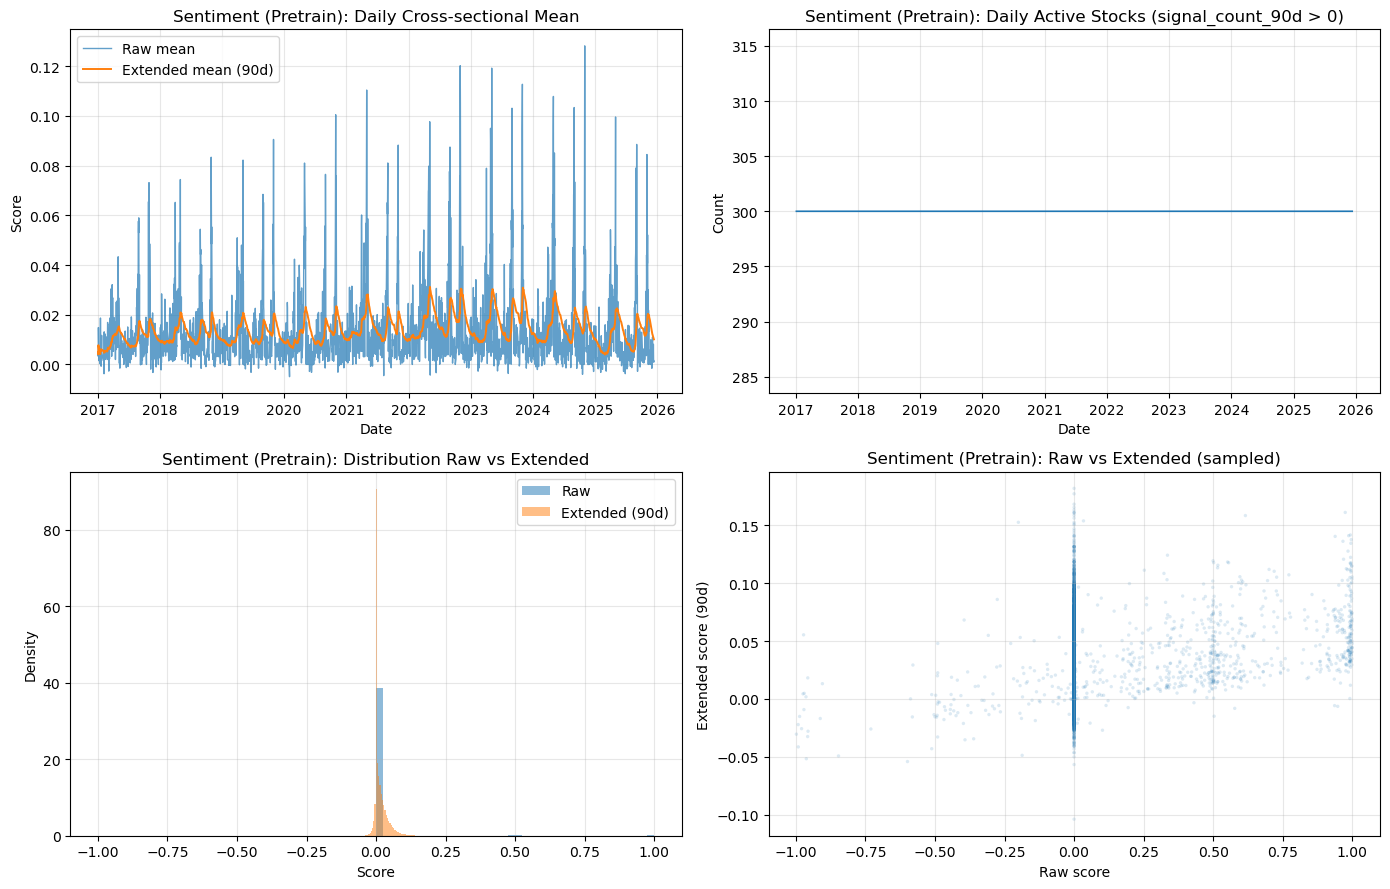


Using finetuned regression source: finetuned_regression_score_extended_90d_unified.csv

--- Finetuned Regression ---
Summary of extended score:
count    812700.000000
mean          0.002853
std           0.005956
min          -0.025479
25%           0.000000
50%           0.000102
75%           0.003788
max           0.109782

Daily active stocks (signal_count_90d>0) summary:
count    2709.0
mean      300.0
std         0.0
min       300.0
25%       300.0
50%       300.0
75%       300.0
max       300.0


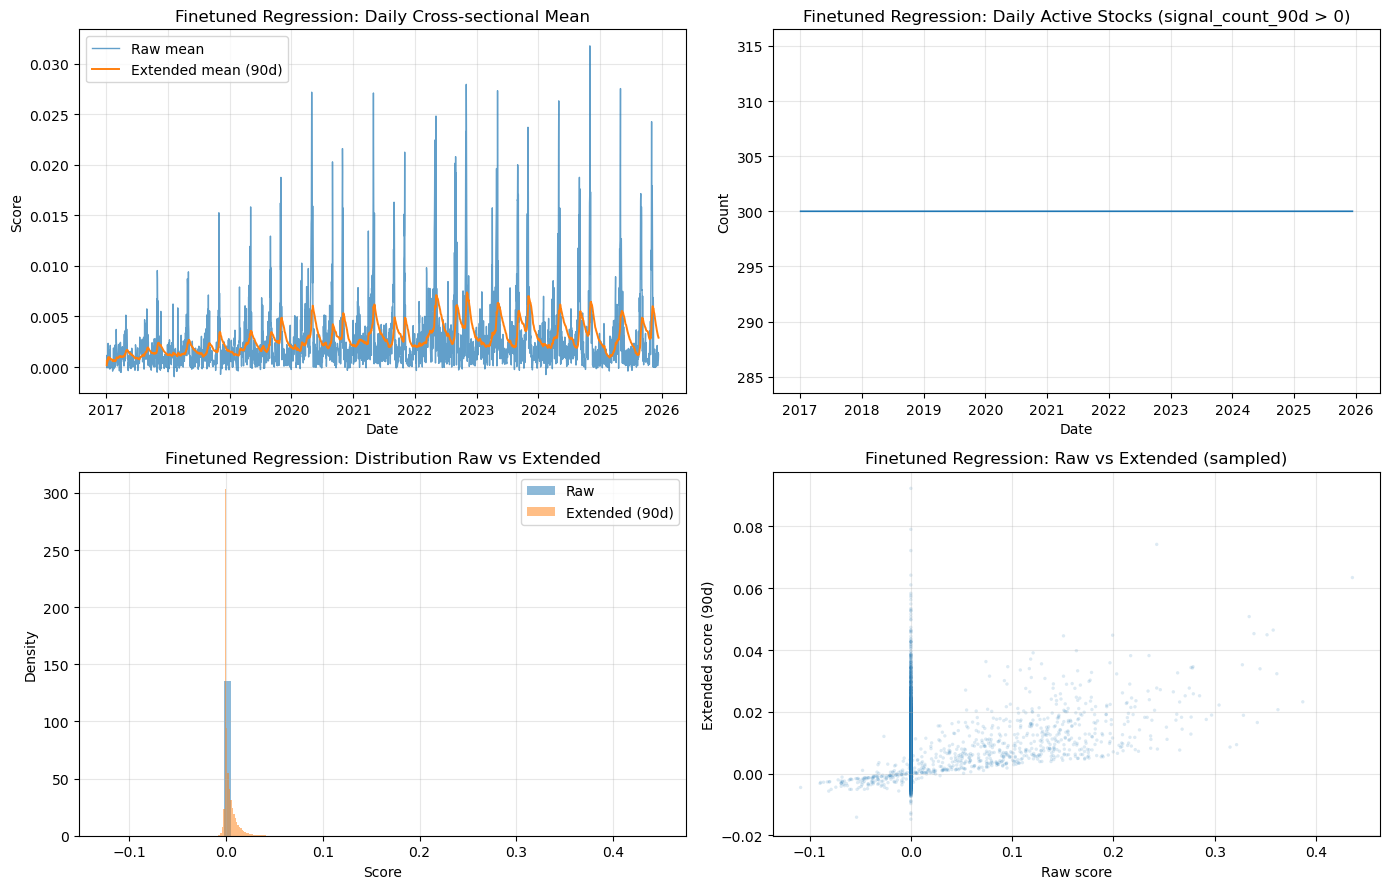


Using finetuned 3class source: finetuned_3class_score_extended_90d_unified.csv

--- Finetuned 3Class ---
Summary of extended score:
count    812700.000000
mean          0.000520
std           0.009551
min          -0.157046
25%          -0.001428
50%           0.000000
75%           0.001267
max           0.143925

Daily active stocks (signal_count_90d>0) summary:
count    2709.0
mean      300.0
std         0.0
min       300.0
25%       300.0
50%       300.0
75%       300.0
max       300.0


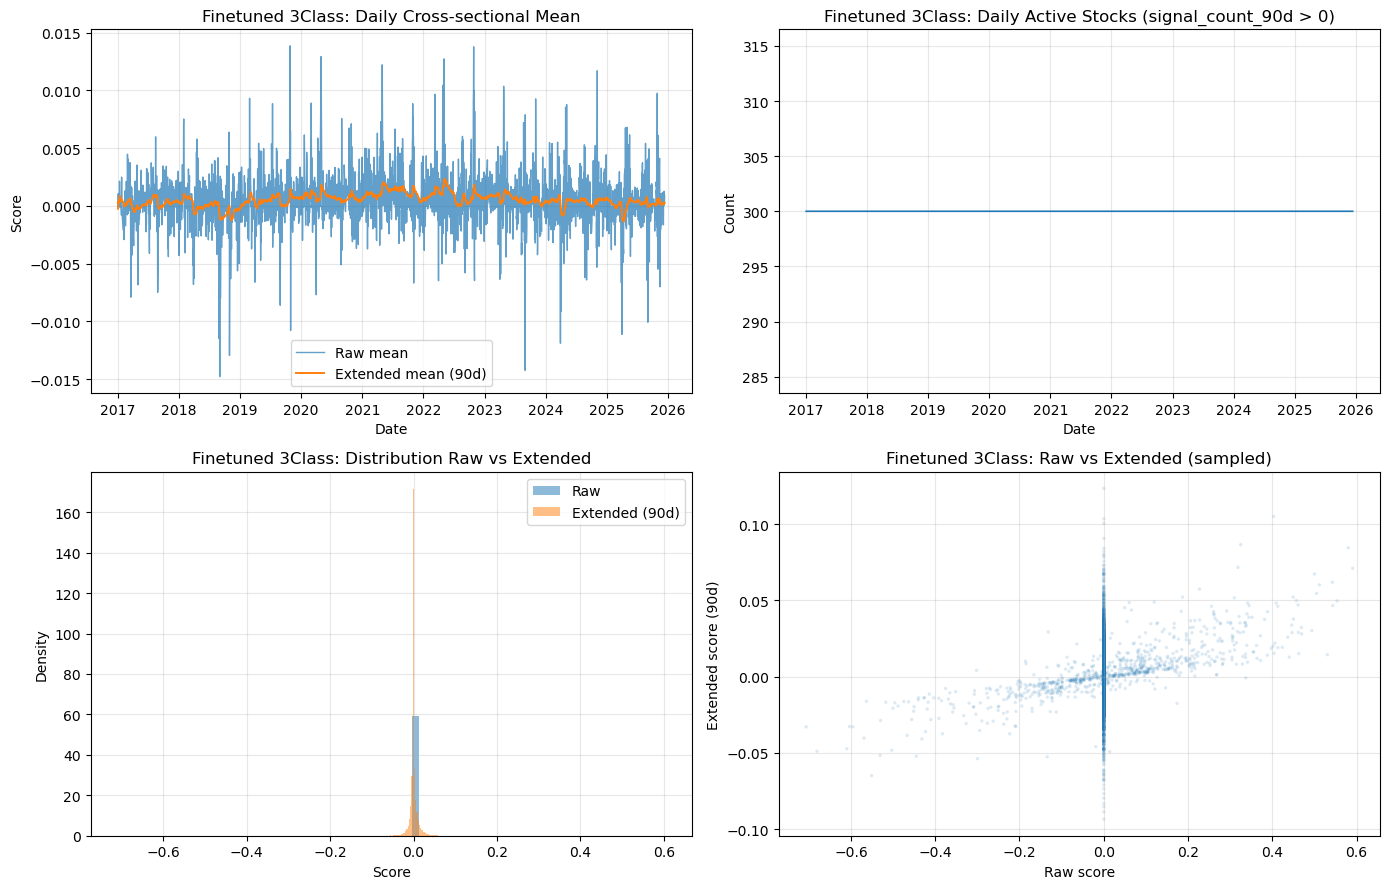


✅ Extended score visualization complete (sentiment + finetuned regression + finetuned 3class)


In [30]:
# 4.2a+++: Visually expanded score (Sentiment + Finetuned Regression + Finetuned 3Class)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 72)
print("VISUALIZE EXTENDED SCORES (90D TIME-DECAY): SENTIMENT + FINETUNED")
print("=" * 72)


def load_summary_with_fallback(candidates: list[Path], required_cols: set):
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f"No summary file found in candidates: {[str(x) for x in candidates]}")
    df = pd.read_csv(path)
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {path.name}: {missing}")
    return df, path


def visualize_extended_summary(
    vis_df: pd.DataFrame,
    date_col: str,
    raw_col: str,
    ext_col: str,
    count_col: str,
    title_prefix: str,
):
    vis_df = vis_df.copy()
    vis_df[date_col] = pd.to_datetime(vis_df[date_col].astype(str), errors="coerce")
    vis_df[raw_col] = pd.to_numeric(vis_df[raw_col], errors="coerce")
    vis_df[ext_col] = pd.to_numeric(vis_df[ext_col], errors="coerce")
    vis_df[count_col] = pd.to_numeric(vis_df[count_col], errors="coerce")

    vis_df = vis_df.dropna(subset=[date_col, ext_col]).copy()
    if vis_df.empty:
        raise ValueError(f"No valid rows to visualize for {title_prefix}")

    daily = vis_df.groupby(date_col, as_index=False).agg(
        raw_mean=(raw_col, "mean"),
        ext_mean=(ext_col, "mean"),
        ext_median=(ext_col, "median"),
        ext_std=(ext_col, "std"),
        active_stock_count=(count_col, lambda x: int((x > 0).sum())),
    )

    print(f"\n--- {title_prefix} ---")
    print("Summary of extended score:")
    print(vis_df[ext_col].describe().to_string())
    print("\nDaily active stocks (signal_count_90d>0) summary:")
    print(daily["active_stock_count"].describe().to_string())

    sample_size = min(120000, len(vis_df))
    sample_df = vis_df.sample(n=sample_size, random_state=42) if len(vis_df) > sample_size else vis_df

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.patch.set_facecolor("white")

    # (1) Daily average time series
    axes[0, 0].plot(daily[date_col], daily["raw_mean"], label="Raw mean", linewidth=1.0, alpha=0.7)
    axes[0, 0].plot(daily[date_col], daily["ext_mean"], label="Extended mean (90d)", linewidth=1.4)
    axes[0, 0].set_title(f"{title_prefix}: Daily Cross-sectional Mean")
    axes[0, 0].set_xlabel("Date")
    axes[0, 0].set_ylabel("Score")
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].legend()

    # (2) Number of available signal stocks
    axes[0, 1].plot(daily[date_col], daily["active_stock_count"], color="#1f77b4", linewidth=1.2)
    axes[0, 1].set_title(f"{title_prefix}: Daily Active Stocks (signal_count_90d > 0)")
    axes[0, 1].set_xlabel("Date")
    axes[0, 1].set_ylabel("Count")
    axes[0, 1].grid(alpha=0.3)

    # (3) Distribution comparison histogram
    bins = 80
    axes[1, 0].hist(sample_df[raw_col].dropna(), bins=bins, alpha=0.5, density=True, label="Raw")
    axes[1, 0].hist(sample_df[ext_col].dropna(), bins=bins, alpha=0.5, density=True, label="Extended (90d)")
    axes[1, 0].set_title(f"{title_prefix}: Distribution Raw vs Extended")
    axes[1, 0].set_xlabel("Score")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].legend()

    # (4) Scatter relationship (sampling)
    scatter_n = min(25000, len(sample_df))
    scatter_df = sample_df.sample(n=scatter_n, random_state=7) if len(sample_df) > scatter_n else sample_df
    axes[1, 1].scatter(
        scatter_df[raw_col],
        scatter_df[ext_col],
        s=6,
        alpha=0.15,
        edgecolors="none"
    )
    axes[1, 1].set_title(f"{title_prefix}: Raw vs Extended (sampled)")
    axes[1, 1].set_xlabel("Raw score")
    axes[1, 1].set_ylabel("Extended score (90d)")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# 1) Pretrain sentiment
if "extended_df" in globals() and isinstance(extended_df, pd.DataFrame) and not extended_df.empty and {"date", "raw_signal", "extended_sentiment_90d", "signal_count_90d"}.issubset(extended_df.columns):
    sent_df = extended_df.copy().rename(columns={"raw_signal": "raw_sentiment"})
    sent_source = Path("<memory:extended_df>")
else:
    sent_df, sent_source = load_summary_with_fallback(
        [Path("sentiment_score_extended_90d_unified.csv"), Path("sentiment_score_extended_90d.csv")],
        {"date", "raw_signal", "extended_sentiment_90d", "signal_count_90d"},
    )
    sent_df = sent_df.rename(columns={"raw_signal": "raw_sentiment"})

print(f"\nUsing sentiment source: {sent_source}")
visualize_extended_summary(
    vis_df=sent_df,
    date_col="date",
    raw_col="raw_sentiment",
    ext_col="extended_sentiment_90d",
    count_col="signal_count_90d",
    title_prefix="Sentiment (Pretrain)",
)

# 2) Finetuned regression
reg_df, reg_source = load_summary_with_fallback(
    [Path("finetuned_regression_score_extended_90d_unified.csv"), Path("finetuned_regression_score_extended_90d.csv")],
    {"date", "raw_signal", "extended_reg_signal_90d", "signal_count_90d"},
)
print(f"\nUsing finetuned regression source: {reg_source}")
visualize_extended_summary(
    vis_df=reg_df,
    date_col="date",
    raw_col="raw_signal",
    ext_col="extended_reg_signal_90d",
    count_col="signal_count_90d",
    title_prefix="Finetuned Regression",
)

# 3) Finetuned 3class
cls_df, cls_source = load_summary_with_fallback(
    [Path("finetuned_3class_score_extended_90d_unified.csv"), Path("finetuned_3class_score_extended_90d.csv")],
    {"date", "raw_signal", "extended_cls_signal_90d", "signal_count_90d"},
)
print(f"\nUsing finetuned 3class source: {cls_source}")
visualize_extended_summary(
    vis_df=cls_df,
    date_col="date",
    raw_col="raw_signal",
    ext_col="extended_cls_signal_90d",
    count_col="signal_count_90d",
    title_prefix="Finetuned 3Class",
)

print("\n✅ Extended score visualization complete (sentiment + finetuned regression + finetuned 3class)")

### Cell 12: Purpose, Formula, and Logic
- **Role**: Compute step: from pathlib import Path
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $y=f(x)$ with deterministic transformation steps encoded in this cell.


In [31]:
from pathlib import Path
import pandas as pd
from backtest import validate_weights

print("="*72)
print("4.2a BUILD DAILY PORTFOLIOS (PRETRAIN SENTIMENT + FINETUNED REG + FINETUNED 3CLASS)")
print("="*72)

# Unified reading of unified extending output (no more falling back to the old directory)
sent_scores_dir = Path("sentiment_scores_by_day_ext90_unified")
reg_scores_dir = Path("finetuned_scores_regression_by_day_ext90_unified")
cls_scores_dir = Path("finetuned_scores_3class_by_day_ext90_unified")

if not sent_scores_dir.exists() or not sent_scores_dir.is_dir():
    raise FileNotFoundError("pretrain sentiment ext90 unified directory not found")
if not reg_scores_dir.exists() or not reg_scores_dir.is_dir():
    raise FileNotFoundError("finetuned regression ext90 unified directory not found")
if not cls_scores_dir.exists() or not cls_scores_dir.is_dir():
    raise FileNotFoundError("finetuned 3class ext90 unified directory not found")

sent_weight_file = Path("pretrain_sent_weight_daily_common_start.csv")
reg_weight_file = Path("finetuned_reg_weight_daily_common_start.csv")
cls_weight_file = Path("finetuned_3class_weight_daily_common_start.csv")


def _first_valid_date(scores_dir: Path):
    for file_path in sorted(scores_dir.glob("*_data.csv")):
        date_str = file_path.stem.replace("_data", "")
        if date_str.isdigit() and len(date_str) == 8:
            dt = pd.to_datetime(date_str, format="%Y%m%d", errors="coerce")
            if not pd.isna(dt):
                return dt
    return None


first_sent = _first_valid_date(sent_scores_dir)
first_reg = _first_valid_date(reg_scores_dir)
first_cls = _first_valid_date(cls_scores_dir)
if any(x is None for x in [first_sent, first_reg, first_cls]):
    raise ValueError("Cannot infer start date from one or more score directories.")

# Unified starting point: All three models start from the latest commonly available start date
COMMON_START_DATE = max(first_sent, first_reg, first_cls)
print(f"[*] Common portfolio start date: {COMMON_START_DATE:%Y-%m-%d}")


def build_market_neutral_weights(scores_dir: Path, signal_col: str, out_file: Path, label: str):
    rows = []
    prev_positions = None

    for file_path in sorted(scores_dir.glob("*_data.csv")):
        date_str = file_path.stem.replace("_data", "")
        if not (date_str.isdigit() and len(date_str) == 8):
            continue
        dt = pd.to_datetime(date_str, format="%Y%m%d", errors="coerce")
        if pd.isna(dt) or dt < COMMON_START_DATE:
            continue

        df = pd.read_csv(file_path)
        required_cols = {"stock", "name", signal_col}
        if not required_cols.issubset(df.columns):
            continue

        day = df.copy()
        day["stock"] = day["stock"].astype(str).str.zfill(6)
        day["name"] = day["name"].astype(str)
        day["signal"] = pd.to_numeric(day[signal_col], errors="coerce")
        day = day.dropna(subset=["stock", "signal"])
        day = day[day["stock"] != ""]
        day = day.sort_values("signal", ascending=False).reset_index(drop=True)

        available_count = int(len(day))

        # Rule 1: If the number of stocks available on the day is < 40, there will be no position adjustment and the previous day’s weight will be used.
        if available_count < 40:
            if prev_positions is None or prev_positions.empty:
                continue
            day_positions = prev_positions.copy()
            day_positions["date"] = date_str
            day_positions["available_score_count"] = available_count
            day_positions["action"] = "carry_forward"
            rows.extend(day_positions[["date", "stock", "name", "signal", "weight", "available_score_count", "action"]].values.tolist())
            continue

        # Rule 2: Construct long-short according to 20% quantile (top 20% long, bottom 20% short)
        n_bucket = int(available_count * 0.2)
        if n_bucket <= 0:
            if prev_positions is None or prev_positions.empty:
                continue
            day_positions = prev_positions.copy()
            day_positions["date"] = date_str
            day_positions["available_score_count"] = available_count
            day_positions["action"] = "carry_forward"
            rows.extend(day_positions[["date", "stock", "name", "signal", "weight", "available_score_count", "action"]].values.tolist())
            continue

        longs = day.head(n_bucket).copy()
        shorts = day.tail(n_bucket).copy()

        lw = 0.5 / n_bucket
        sw = -0.5 / n_bucket
        day_positions = pd.concat([
            longs.assign(weight=lw)[["stock", "name", "signal", "weight"]],
            shorts.assign(weight=sw)[["stock", "name", "signal", "weight"]],
        ], ignore_index=True)

        day_positions["date"] = date_str
        day_positions["available_score_count"] = available_count
        day_positions["action"] = "rebalance"
        rows.extend(day_positions[["date", "stock", "name", "signal", "weight", "available_score_count", "action"]].values.tolist())

        prev_positions = day_positions[["stock", "name", "signal", "weight"]].copy()

    if not rows:
        raise ValueError(f"No weight rows generated for {label}.")

    weights_df = pd.DataFrame(rows, columns=["date", "stock", "name", "sentiment", "weight", "available_score_count", "action"])
    weights_df.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"✓ {label} weights saved: {out_file} | rows={len(weights_df):,}")
    return weights_df


sent_weights_df = build_market_neutral_weights(
    scores_dir=sent_scores_dir,
    signal_col="extended_sentiment_90d",
    out_file=sent_weight_file,
    label="Pretrain Sentiment",
)

reg_weights_df = build_market_neutral_weights(
    scores_dir=reg_scores_dir,
    signal_col="extended_reg_signal_90d",
    out_file=reg_weight_file,
    label="Finetuned Regression",
)

cls_weights_df = build_market_neutral_weights(
    scores_dir=cls_scores_dir,
    signal_col="extended_cls_signal_90d",
    out_file=cls_weight_file,
    label="Finetuned 3Class",
)

print("\n[*] Validate generated weight files...")
for wf in [sent_weight_file, reg_weight_file, cls_weight_file]:
    validate_weights(str(wf))

print("\n" + "="*72)
print("✅ 4.2a PORTFOLIOS COMPLETE (PRETRAIN + FINETUNED REG + FINETUNED 3CLASS, SAME START DATE)")
print("="*72)

4.2a BUILD DAILY PORTFOLIOS (PRETRAIN SENTIMENT + FINETUNED REG + FINETUNED 3CLASS)
[*] Common portfolio start date: 2017-01-04
✓ Pretrain Sentiment weights saved: pretrain_sent_weight_daily_common_start.csv | rows=325,080
✓ Finetuned Regression weights saved: finetuned_reg_weight_daily_common_start.csv | rows=325,080
✓ Finetuned 3Class weights saved: finetuned_3class_weight_daily_common_start.csv | rows=325,080

[*] Validate generated weight files...

[*] Validating weights: pretrain_sent_weight_daily_common_start.csv
  rows: 325,080
  unique dates: 2709
  duplicate (date, stock): 0
  median gross leverage: 1.0000
  max gross leverage: 1.0000
  max abs net weight: 0.000000e+00

[*] Validating weights: finetuned_reg_weight_daily_common_start.csv
  rows: 325,080
  unique dates: 2709
  duplicate (date, stock): 0
  median gross leverage: 1.0000
  max gross leverage: 1.0000
  max abs net weight: 0.000000e+00

[*] Validating weights: finetuned_3class_weight_daily_common_start.csv
  rows: 32

### Cell 13: Purpose, Formula, and Logic
- **Role**: Compute step: from backtest import run_backtest
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $\mathrm{Sharpe}=\frac{\mathbb{E}[r]}{\sigma(r)}\sqrt{252}$, and $\mathrm{NAV}_t=\prod_{i\le t}(1+r_i)$.


In [32]:
from backtest import run_backtest
from pathlib import Path
import numpy as np
import pandas as pd

print("="*72)
print("4.2b DAILY BACKTEST (PRETRAIN SENTIMENT + FINETUNED REG + FINETUNED 3CLASS)")
print("="*72)

OOS_START_DATE = pd.Timestamp("2021-01-01")

sent_weight_file = Path("pretrain_sent_weight_daily_common_start.csv")
reg_weight_file = Path("finetuned_reg_weight_daily_common_start.csv")
cls_weight_file = Path("finetuned_3class_weight_daily_common_start.csv")

for wf in [sent_weight_file, reg_weight_file, cls_weight_file]:
    if not wf.exists():
        raise FileNotFoundError(f"Weight file not found: {wf}")

print("\n[*] Step 1: Load weight CSVs (common start)")
sent_preview = pd.read_csv(sent_weight_file)
reg_preview = pd.read_csv(reg_weight_file)
cls_preview = pd.read_csv(cls_weight_file)
print(f"  SENT rows={len(sent_preview):,}, dates={sent_preview['date'].nunique()}, stocks={sent_preview['stock'].nunique()}")
print(f"  REG  rows={len(reg_preview):,}, dates={reg_preview['date'].nunique()}, stocks={reg_preview['stock'].nunique()}")
print(f"  CLS  rows={len(cls_preview):,}, dates={cls_preview['date'].nunique()}, stocks={cls_preview['stock'].nunique()}")

print("\n[*] Step 2: Run daily backtests on DuckDB...")
pretrain_sent_common_start_results = run_backtest(
    weights_file=str(sent_weight_file),
    strategy_name="Pretrain Sentiment EXT90 (Common Start)",
    visualize=False,
    duckdb_path="../trading_data.duckdb",
    execution_lag_days=1,
)

finetuned_reg_common_start_results = run_backtest(
    weights_file=str(reg_weight_file),
    strategy_name="Finetuned Regression EXT90 (Common Start)",
    visualize=False,
    duckdb_path="../trading_data.duckdb",
    execution_lag_days=1,
)

finetuned_cls_common_start_results = run_backtest(
    weights_file=str(cls_weight_file),
    strategy_name="Finetuned 3Class EXT90 (Common Start)",
    visualize=False,
    duckdb_path="../trading_data.duckdb",
    execution_lag_days=1,
)

# keep compatibility with downstream cells
sentiment_results = pretrain_sent_common_start_results
inference_results = finetuned_cls_common_start_results

# backward-compatible aliases
pretrain_sent_oos_results = pretrain_sent_common_start_results
finetuned_reg_oos_results = finetuned_reg_common_start_results
finetuned_cls_oos_results = finetuned_cls_common_start_results

# save returns
pretrain_sent_ret = pretrain_sent_common_start_results["returns"].copy()
finetuned_reg_ret = finetuned_reg_common_start_results["returns"].copy()
finetuned_cls_ret = finetuned_cls_common_start_results["returns"].copy()
pretrain_sent_ret.to_csv("backtest_pretrain_sent_common_start.csv", index=False, encoding="utf-8-sig")
finetuned_reg_ret.to_csv("backtest_finetuned_reg_common_start.csv", index=False, encoding="utf-8-sig")
finetuned_cls_ret.to_csv("backtest_finetuned_cls3_common_start.csv", index=False, encoding="utf-8-sig")

def _extract_daily_ret(result_obj: dict, result_name: str) -> pd.DataFrame:
    if not isinstance(result_obj, dict) or "returns" not in result_obj:
        raise ValueError(f"{result_name} missing valid returns.")
    df = result_obj["returns"].copy()
    cols = [str(c) for c in df.columns]

    date_col = next((c for c in cols if c.lower() in {"date", "trade_date", "交易日期"}), None)
    ret_col = next((c for c in cols if c.lower() in {"portfolio_ret", "nlp_ret", "nlp_return", "strategy_ret", "daily_return", "组合收益"}), None)

    if ret_col is None:
        ret_col = next((c for c in cols if ("portfolio" in c.lower() or "nlp" in c.lower() or "strategy" in c.lower()) and ("ret" in c.lower() or "return" in c.lower())), None)
    if date_col is None:
        date_col = cols[0] if len(cols) > 0 else None
    if date_col is None or ret_col is None:
        raise ValueError(f"Cannot infer date/return columns from {result_name}. Columns found: {cols}")

    out = df[[date_col, ret_col]].copy()
    out = out.rename(columns={date_col: "date", ret_col: "ret"})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["ret"] = pd.to_numeric(out["ret"], errors="coerce")
    out = out.dropna(subset=["date", "ret"]).sort_values("date").reset_index(drop=True)
    return out

def perf_stats(daily_ret: pd.Series) -> dict:
    r = pd.Series(daily_ret).dropna()
    if len(r) == 0:
        return {"ann_return": np.nan, "ann_vol": np.nan, "sharpe": np.nan, "max_dd": np.nan, "total_return": np.nan, "n_days": 0}
    nav = (1 + r).cumprod()
    ann_return = nav.iloc[-1] ** (252 / len(r)) - 1
    ann_vol = r.std(ddof=0) * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan
    max_dd = (nav / nav.cummax() - 1).min()
    total_return = nav.iloc[-1] - 1
    return {
        "ann_return": float(ann_return),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,
        "max_dd": float(max_dd),
        "total_return": float(total_return),
        "n_days": int(len(r)),
    }

def build_period_metrics(series_df: pd.DataFrame, strategy_name: str) -> list[dict]:
    full = series_df["ret"]
    oos = series_df.loc[series_df["date"] >= OOS_START_DATE, "ret"]
    return [
        {"Strategy": strategy_name, "Sample": "Full", **perf_stats(full)},
        {"Strategy": strategy_name, "Sample": "OOS(>=2021-01-01)", **perf_stats(oos)},
    ]

metrics_rows = []
metrics_rows.extend(build_period_metrics(_extract_daily_ret(pretrain_sent_common_start_results, "pretrain_sent_common_start_results"), "Pretrain Sentiment"))
metrics_rows.extend(build_period_metrics(_extract_daily_ret(finetuned_reg_common_start_results, "finetuned_reg_common_start_results"), "Finetuned Regression"))
metrics_rows.extend(build_period_metrics(_extract_daily_ret(finetuned_cls_common_start_results, "finetuned_cls_common_start_results"), "Finetuned 3Class"))
backtest_metrics_df = pd.DataFrame(metrics_rows)

print("\n📊 4.2b Metrics (Full + OOS)")
print(backtest_metrics_df.to_string(index=False, formatters={
    "ann_return": "{:.2%}".format,
    "ann_vol": "{:.2%}".format,
    "sharpe": "{:.3f}".format,
    "max_dd": "{:.2%}".format,
    "total_return": "{:.2%}".format,
}))

print("\n📌 4.2b OOS-only Metrics")
print(backtest_metrics_df[backtest_metrics_df["Sample"] == "OOS(>=2021-01-01)"].to_string(index=False, formatters={
    "ann_return": "{:.2%}".format,
    "ann_vol": "{:.2%}".format,
    "sharpe": "{:.3f}".format,
    "max_dd": "{:.2%}".format,
    "total_return": "{:.2%}".format,
}))

print("\n" + "="*72)
print("✅ 4.2b BACKTEST COMPLETE (COMMON START)")
print("="*72)
print("Saved:")
print("  - backtest_pretrain_sent_common_start.csv")
print("  - backtest_finetuned_reg_common_start.csv")
print("  - backtest_finetuned_cls3_common_start.csv")

4.2b DAILY BACKTEST (PRETRAIN SENTIMENT + FINETUNED REG + FINETUNED 3CLASS)

[*] Step 1: Load weight CSVs (common start)
  SENT rows=325,080, dates=2709, stocks=300
  REG  rows=325,080, dates=2709, stocks=300
  CLS  rows=325,080, dates=2709, stocks=297

[*] Step 2: Run daily backtests on DuckDB...

RUNNING DAILY BACKTEST: Pretrain Sentiment EXT90 (Common Start)

BACKTEST RESULTS (DAILY)

Total Cumulative Returns:
  Portfolio:    38.97%
  HS300:        39.05%
  Excess:       -0.08%

Annualized Risk Metrics:
  Portfolio Sharpe:        0.5961
  Benchmark Sharpe:        0.2989
  Information Ratio:      -0.0909

Portfolio Stats:
  Annual Return:            3.90%
  Annual Vol:               6.81%
  Max Drawdown:           -29.94%
  Win Rate:                50.60%


RUNNING DAILY BACKTEST: Finetuned Regression EXT90 (Common Start)

BACKTEST RESULTS (DAILY)

Total Cumulative Returns:
  Portfolio:   124.72%
  HS300:        39.05%
  Excess:       85.67%

Annualized Risk Metrics:
  Portfolio Shar

### Cell 14: Purpose, Formula, and Logic
- **Role**: Compute step: # 4.2c Model Backtest Preparation: Pretrain + Finetuned models + HS300 benchmark
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $\mathrm{Sharpe}=\frac{\mathbb{E}[r]}{\sigma(r)}\sqrt{252}$, and $\mathrm{NAV}_t=\prod_{i\le t}(1+r_i)$.


In [42]:
# 4.2c Model Backtest Preparation: Pretrain + Finetuned models + HS300 benchmark
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb

print("="*60)
print("4.2c PREP MODEL RETURNS (+ HS300 BENCHMARK)")
print("="*60)

OOS_START_DATE = pd.Timestamp("2021-01-01")

if "pretrain_sent_oos_results" not in globals() or not pretrain_sent_oos_results:
    raise ValueError("pretrain_sent_oos_results is missing. Please run 4.2b first.")
if "finetuned_reg_oos_results" not in globals() or not finetuned_reg_oos_results:
    raise ValueError("finetuned_reg_oos_results is missing. Please run 4.2b first.")
if "finetuned_cls_oos_results" not in globals() or not finetuned_cls_oos_results:
    raise ValueError("finetuned_cls_oos_results is missing. Please run 4.2b first.")

def _extract_return_series(result_obj: dict, result_name: str) -> pd.DataFrame:
    if not isinstance(result_obj, dict) or "returns" not in result_obj:
        raise ValueError(f"{result_name} is missing valid backtest result dict with 'returns'.")

    df = result_obj["returns"].copy()
    cols = [str(c) for c in df.columns]

    date_col = next((c for c in cols if c.lower() in {"date", "trade_date", "交易日期"}), None)
    ret_col = next((c for c in cols if c.lower() in {"portfolio_ret", "nlp_ret", "nlp_return", "strategy_ret", "daily_return", "组合收益"}), None)

    if ret_col is None:
        ret_col = next((c for c in cols if ("portfolio" in c.lower() or "nlp" in c.lower() or "strategy" in c.lower()) and ("ret" in c.lower() or "return" in c.lower())), None)
    if date_col is None:
        date_col = cols[0] if len(cols) > 0 else None

    if date_col is None or ret_col is None:
        raise ValueError(f"Cannot infer date/return columns from {result_name}. Columns found: {cols}")

    out = df[[date_col, ret_col]].copy()
    out = out.rename(columns={date_col: "date", ret_col: "ret"})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["ret"] = pd.to_numeric(out["ret"], errors="coerce")
    out = out.dropna(subset=["date", "ret"]).sort_values("date").reset_index(drop=True)
    return out

pretrain_df = _extract_return_series(pretrain_sent_oos_results, "pretrain_sent_oos_results")
reg_df = _extract_return_series(finetuned_reg_oos_results, "finetuned_reg_oos_results")
cls_df = _extract_return_series(finetuned_cls_oos_results, "finetuned_cls_oos_results")

ret_df = pretrain_df.rename(columns={"ret": "portfolio_ret"}).copy()
ret_df = ret_df.merge(reg_df.rename(columns={"ret": "finetuned_reg_ret"}), on="date", how="left")
ret_df = ret_df.merge(cls_df.rename(columns={"ret": "finetuned_cls_ret"}), on="date", how="left")
ret_df["finetuned_reg_ret"] = ret_df["finetuned_reg_ret"].fillna(0.0)
ret_df["finetuned_cls_ret"] = ret_df["finetuned_cls_ret"].fillna(0.0)

# ---- Load HS300 daily return from DuckDB ----
db_candidates = [Path("../trading_data.duckdb"), Path("trading_data.duckdb"), Path.cwd() / "trading_data.duckdb"]
duckdb_path = next((p for p in db_candidates if p.exists()), db_candidates[0])
con = duckdb.connect(str(duckdb_path), read_only=True)
try:
    hs300_df = con.execute(
        """
        WITH base AS (
            SELECT
                trade_date,
                LPAD(REGEXP_EXTRACT(COALESCE(stock_code, ''), '([0-9]+)', 1), 6, '0') AS code6,
                COALESCE(
                    change_pct,
                    CASE WHEN prev_close IS NOT NULL AND prev_close <> 0 AND close IS NOT NULL
                         THEN ((close - prev_close) / prev_close) * 100
                         ELSE NULL
                    END
                ) AS ret_pct
            FROM trading_data_clean
            WHERE trade_date IS NOT NULL
        )
        SELECT
            trade_date AS date,
            AVG(CASE WHEN code6 = '000300' THEN ret_pct END) / 100.0 AS hs300_ret
        FROM base
        WHERE ret_pct IS NOT NULL
        GROUP BY trade_date
        ORDER BY trade_date
        """
    ).fetchdf()
finally:
    con.close()

hs300_df["date"] = pd.to_datetime(hs300_df["date"], errors="coerce")
hs300_df["hs300_ret"] = pd.to_numeric(hs300_df["hs300_ret"], errors="coerce")
hs300_df = hs300_df.dropna(subset=["date"])[["date", "hs300_ret"]]

ret_df = ret_df.merge(hs300_df, on="date", how="left")
ret_df["hs300_ret"] = ret_df["hs300_ret"].fillna(0.0)

def _nav(series: pd.Series) -> pd.Series:
    return (1.0 + pd.Series(series).fillna(0.0)).cumprod()

ret_df["sentiment_nav"] = _nav(ret_df["portfolio_ret"])
ret_df["finetuned_reg_nav"] = _nav(ret_df["finetuned_reg_ret"])
ret_df["finetuned_cls_nav"] = _nav(ret_df["finetuned_cls_ret"])
ret_df["hs300_nav"] = _nav(ret_df["hs300_ret"])

def perf_stats(daily_ret: pd.Series, benchmark_ret: pd.Series | None = None) -> dict:
    r = pd.Series(daily_ret).dropna()
    if len(r) == 0:
        return {
            "ann_return": np.nan,
            "ann_vol": np.nan,
            "sharpe": np.nan,
            "information_ratio": np.nan,
            "max_dd": np.nan,
            "total_return": np.nan,
            "n_days": 0,
        }

    nav = (1 + r).cumprod()
    ann_return = nav.iloc[-1] ** (252 / len(r)) - 1
    ann_vol = r.std(ddof=0) * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan
    max_dd = (nav / nav.cummax() - 1).min()
    total_return = nav.iloc[-1] - 1

    information_ratio = np.nan
    if benchmark_ret is not None:
        b = pd.Series(benchmark_ret).reindex(r.index)
        active = r - b
        tracking_err = active.std(ddof=0) * np.sqrt(252)
        active_ann = active.mean() * 252
        information_ratio = active_ann / tracking_err if tracking_err > 1e-12 else np.nan

    return {
        "ann_return": float(ann_return),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,
        "information_ratio": float(information_ratio) if pd.notna(information_ratio) else np.nan,
        "max_dd": float(max_dd),
        "total_return": float(total_return),
        "n_days": int(len(r)),
    }

series_map = {
    "Pretrain Sentiment": ret_df["portfolio_ret"],
    "Finetuned Regression": ret_df["finetuned_reg_ret"],
    "Finetuned 3Class": ret_df["finetuned_cls_ret"],
    "HS300": ret_df["hs300_ret"],
}

metrics_rows = []
benchmark_series = ret_df["hs300_ret"]
for strategy_name, series in series_map.items():
    benchmark_arg = None if strategy_name == "HS300" else benchmark_series
    oos_mask = ret_df["date"] >= OOS_START_DATE
    metrics_rows.append({"Strategy": strategy_name, "Sample": "Full", **perf_stats(series, benchmark_arg)})
    metrics_rows.append({
        "Strategy": strategy_name,
        "Sample": "OOS(>=2021-01-01)",
        **perf_stats(series[oos_mask], benchmark_arg[oos_mask] if benchmark_arg is not None else None),
    })

overlay_metrics_df = pd.DataFrame(metrics_rows)

overlay_results = {
    "oos_start_date": OOS_START_DATE,
    "returns": ret_df[[
        "date",
        "portfolio_ret", "finetuned_reg_ret", "finetuned_cls_ret", "hs300_ret",
        "sentiment_nav", "finetuned_reg_nav", "finetuned_cls_nav", "hs300_nav",
    ]].copy(),
    "metrics": overlay_metrics_df.copy(),
}

print(f"Using DuckDB: {duckdb_path}")
print(f"Rows prepared: {len(ret_df):,}")
print("\n📊 4.2c Model Metrics (Full + OOS, with HS300 benchmark)")
print(overlay_metrics_df.to_string(index=False, formatters={
    "ann_return": "{:.2%}".format,
    "ann_vol": "{:.2%}".format,
    "sharpe": "{:.3f}".format,
    "information_ratio": "{:.3f}".format,
    "max_dd": "{:.2%}".format,
    "total_return": "{:.2%}".format,
}))

print("\n📌 4.2c OOS-only Metrics")
print(overlay_metrics_df[overlay_metrics_df["Sample"] == "OOS(>=2021-01-01)"].to_string(index=False, formatters={
    "ann_return": "{:.2%}".format,
    "ann_vol": "{:.2%}".format,
    "sharpe": "{:.3f}".format,
    "information_ratio": "{:.3f}".format,
    "max_dd": "{:.2%}".format,
    "total_return": "{:.2%}".format,
}))
print("✓ Model preparation complete (+ HS300 benchmark)")

4.2c PREP MODEL RETURNS (+ HS300 BENCHMARK)
Using DuckDB: trading_data.duckdb
Rows prepared: 2,168

📊 4.2c Model Metrics (Full + OOS, with HS300 benchmark)
            Strategy            Sample ann_return ann_vol sharpe information_ratio  max_dd total_return  n_days
  Pretrain Sentiment              Full      3.90%   6.81%  0.573            -0.091 -29.94%       38.97%    2168
  Pretrain Sentiment OOS(>=2021-01-01)     -3.41%   6.55% -0.520            -0.132 -29.94%      -15.15%    1194
Finetuned Regression              Full      9.87%   9.39%  1.051             0.250 -28.12%      124.72%    2168
Finetuned Regression OOS(>=2021-01-01)     -2.55%  10.04% -0.254            -0.066 -28.12%      -11.54%    1194
    Finetuned 3Class              Full      7.44%   6.89%  1.080             0.102 -33.20%       85.46%    2168
    Finetuned 3Class OOS(>=2021-01-01)     -5.77%   7.31% -0.790            -0.269 -33.20%      -24.55%    1194
               HS300              Full      3.91%  18.64%  0

### Cell 15: Purpose, Formula, and Logic
- **Role**: Compute step: import numpy as np
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $\mathrm{Sharpe}=\frac{\mathbb{E}[r]}{\sigma(r)}\sqrt{252}$, and $\mathrm{NAV}_t=\prod_{i\le t}(1+r_i)$.



UNIFIED BACKTEST VISUALIZATION (MODEL + HS300)

📊 Unified Metrics Table (Full + OOS)
            Strategy            Sample ann_return ann_vol sharpe information_ratio  max_dd total_return  n_days
  Pretrain Sentiment              Full      3.90%   6.81%  0.573            -0.091 -29.94%       38.97%    2168
  Pretrain Sentiment OOS(>=2021-01-01)     -3.41%   6.55% -0.520            -0.132 -29.94%      -15.15%    1194
Finetuned Regression              Full      9.87%   9.39%  1.051             0.250 -28.12%      124.72%    2168
Finetuned Regression OOS(>=2021-01-01)     -2.55%  10.04% -0.254            -0.066 -28.12%      -11.54%    1194
    Finetuned 3Class              Full      7.44%   6.89%  1.080             0.102 -33.20%       85.46%    2168
    Finetuned 3Class OOS(>=2021-01-01)     -5.77%   7.31% -0.790            -0.269 -33.20%      -24.55%    1194
               HS300              Full      3.91%  18.64%  0.210               NaN -45.51%       39.05%    2168
               HS3

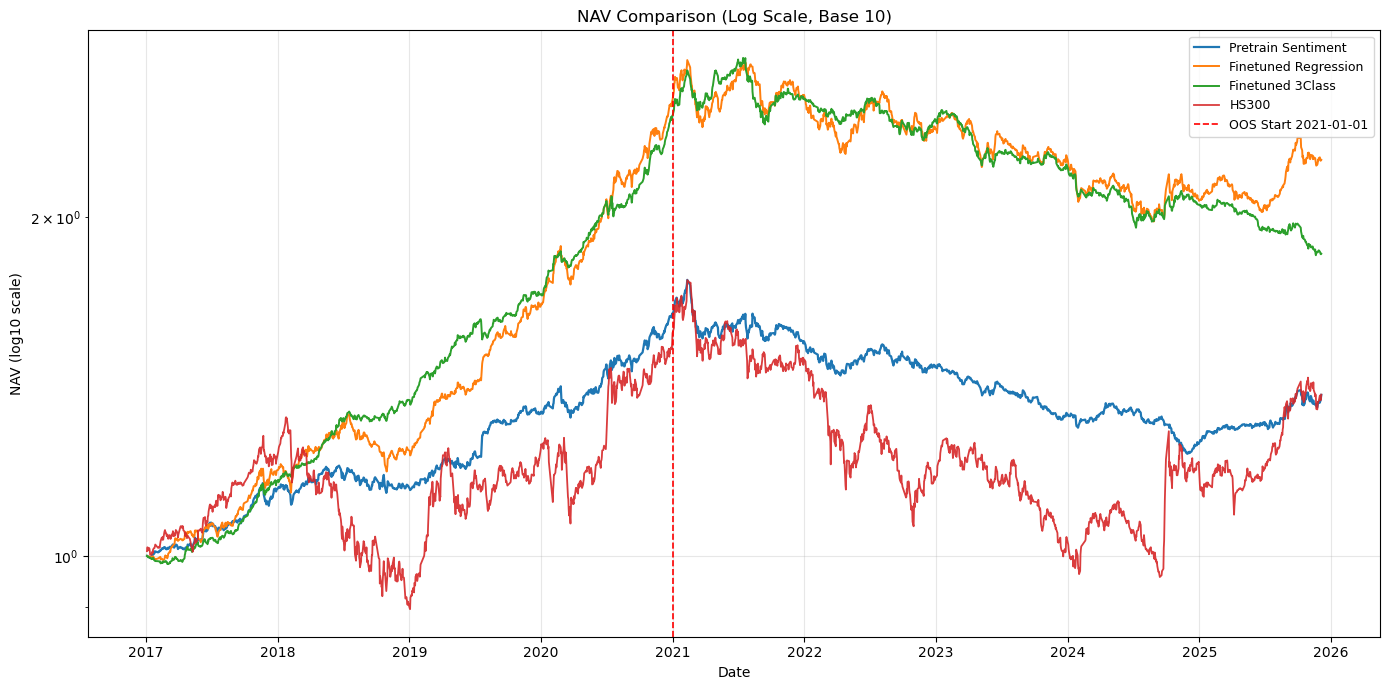

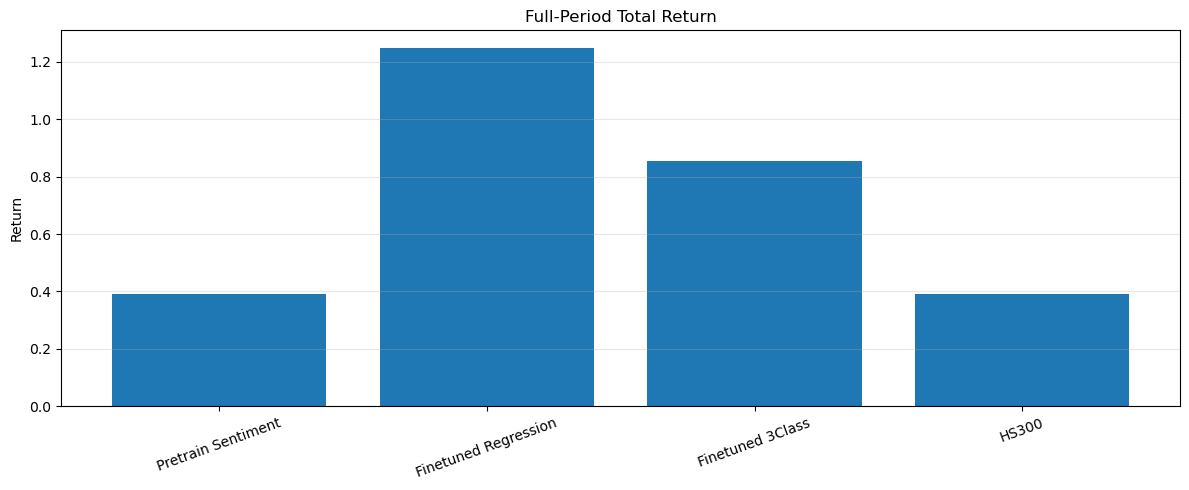

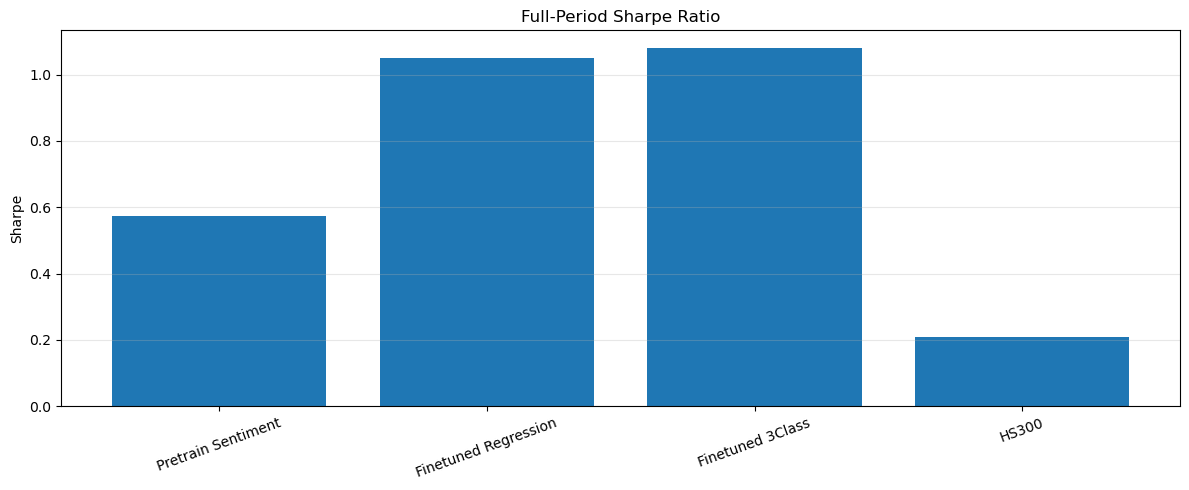

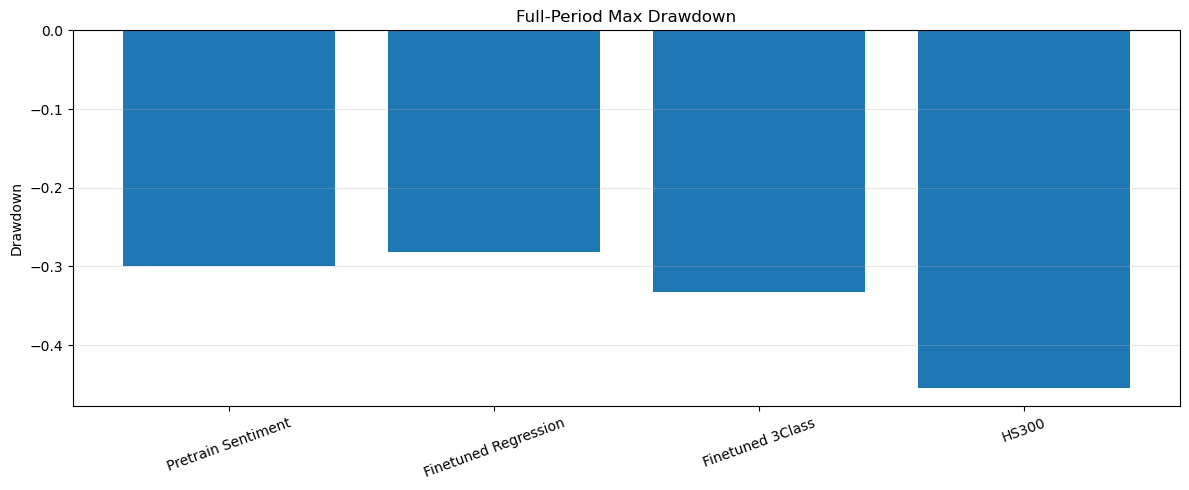

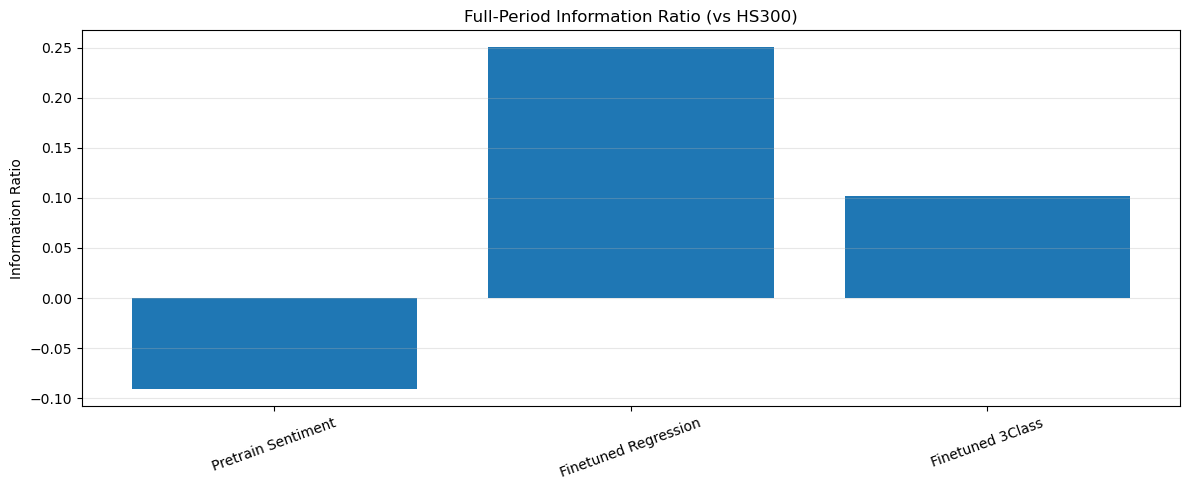


Visualization start date limited to: 2017-01-01

✅ Visualization complete (full-period metrics + full/oos information ratio)


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("UNIFIED BACKTEST VISUALIZATION (MODEL + HS300)")
print("="*60)

OOS_START_DATE = pd.Timestamp("2021-01-01")
VIS_START_DATE = pd.Timestamp("2017-01-01")

if "overlay_results" not in globals() or not overlay_results:
    raise ValueError("overlay_results is missing. Please run cell 14 first.")

def _extract_return_series(result_obj, result_name: str) -> pd.DataFrame:
    if not isinstance(result_obj, dict) or "returns" not in result_obj:
        raise ValueError(f"{result_name} is missing valid backtest result dict with 'returns'.")

    df = result_obj["returns"].copy()
    cols = [str(c) for c in df.columns]

    date_col = next((c for c in cols if c.lower() in {"date", "trade_date", "交易日期"}), None)
    ret_col = next((c for c in cols if c.lower() in {"portfolio_ret", "nlp_ret", "nlp_return", "strategy_ret", "daily_return", "组合收益"}), None)

    if ret_col is None:
        ret_col = next((c for c in cols if ("portfolio" in c.lower() or "nlp" in c.lower() or "strategy" in c.lower()) and ("ret" in c.lower() or "return" in c.lower())), None)
    if date_col is None:
        date_col = cols[0] if len(cols) > 0 else None

    if date_col is None or ret_col is None:
        raise ValueError(f"Cannot infer date/return columns from {result_name} returns. Columns found: {cols}")

    out = df[[date_col, ret_col]].copy()
    out = out.rename(columns={date_col: "date", ret_col: "ret"})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["ret"] = pd.to_numeric(out["ret"], errors="coerce")
    out = out.dropna(subset=["date", "ret"]).sort_values("date").reset_index(drop=True)
    return out

if "pretrain_sent_oos_results" not in globals() or not pretrain_sent_oos_results:
    raise ValueError("pretrain_sent_oos_results is missing. Please run cell 13 first.")
if "finetuned_reg_oos_results" not in globals() or not finetuned_reg_oos_results:
    raise ValueError("finetuned_reg_oos_results is missing. Please run cell 13 first.")
if "finetuned_cls_oos_results" not in globals() or not finetuned_cls_oos_results:
    raise ValueError("finetuned_cls_oos_results is missing. Please run cell 13 first.")

pretrain_df = _extract_return_series(pretrain_sent_oos_results, "pretrain_sent_oos_results")
reg_df = _extract_return_series(finetuned_reg_oos_results, "finetuned_reg_oos_results")
cls_df = _extract_return_series(finetuned_cls_oos_results, "finetuned_cls_oos_results")

ret_df = overlay_results["returns"].copy()
ret_df["date"] = pd.to_datetime(ret_df["date"], errors="coerce")
ret_df = ret_df.sort_values("date").reset_index(drop=True)

# Ensure required columns exist (backward compatibility)
if "finetuned_reg_ret" not in ret_df.columns:
    ret_df = ret_df.merge(reg_df.rename(columns={"ret": "finetuned_reg_ret"}), on="date", how="left")
if "finetuned_cls_ret" not in ret_df.columns:
    ret_df = ret_df.merge(cls_df.rename(columns={"ret": "finetuned_cls_ret"}), on="date", how="left")
ret_df["finetuned_reg_ret"] = ret_df["finetuned_reg_ret"].fillna(0.0)
ret_df["finetuned_cls_ret"] = ret_df["finetuned_cls_ret"].fillna(0.0)

if "hs300_ret" not in ret_df.columns:
    raise ValueError("hs300_ret is missing in overlay_results['returns']. Please rerun cell 14.")
ret_df["hs300_ret"] = pd.to_numeric(ret_df["hs300_ret"], errors="coerce").fillna(0.0)

def perf_stats(daily_ret: pd.Series, benchmark_ret: pd.Series | None = None) -> dict:
    r = pd.Series(daily_ret).dropna()
    if len(r) == 0:
        return {
            "ann_return": np.nan,
            "ann_vol": np.nan,
            "sharpe": np.nan,
            "information_ratio": np.nan,
            "max_dd": np.nan,
            "total_return": np.nan,
            "n_days": 0,
        }

    nav = (1 + r).cumprod()
    ann_return = nav.iloc[-1] ** (252 / len(r)) - 1
    ann_vol = r.std(ddof=0) * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan
    max_dd = (nav / nav.cummax() - 1).min()
    total_return = nav.iloc[-1] - 1

    information_ratio = np.nan
    if benchmark_ret is not None:
        b = pd.Series(benchmark_ret).reindex(r.index)
        active = r - b
        tracking_err = active.std(ddof=0) * np.sqrt(252)
        active_ann = active.mean() * 252
        information_ratio = active_ann / tracking_err if tracking_err > 1e-12 else np.nan

    return {
        "ann_return": float(ann_return),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,
        "information_ratio": float(information_ratio) if pd.notna(information_ratio) else np.nan,
        "max_dd": float(max_dd),
        "total_return": float(total_return),
        "n_days": int(len(r)),
    }

def _nav(series: pd.Series) -> pd.Series:
    return (1.0 + pd.Series(series).fillna(0.0)).cumprod()

ret_df["pretrain_nav"] = _nav(ret_df["portfolio_ret"])
ret_df["finetuned_reg_nav"] = _nav(ret_df["finetuned_reg_ret"])
ret_df["finetuned_cls_nav"] = _nav(ret_df["finetuned_cls_ret"])
ret_df["hs300_nav"] = _nav(ret_df["hs300_ret"])

strategy_ret_map = {
    "Pretrain Sentiment": ret_df["portfolio_ret"],
    "Finetuned Regression": ret_df["finetuned_reg_ret"],
    "Finetuned 3Class": ret_df["finetuned_cls_ret"],
    "HS300": ret_df["hs300_ret"],
}

metrics_rows = []
benchmark_series = ret_df["hs300_ret"]
for strategy_name, series in strategy_ret_map.items():
    benchmark_arg = None if strategy_name == "HS300" else benchmark_series
    metrics_rows.append({"Strategy": strategy_name, "Sample": "Full", **perf_stats(series, benchmark_arg)})
    oos_mask = ret_df["date"] >= OOS_START_DATE
    metrics_rows.append({
        "Strategy": strategy_name,
        "Sample": "OOS(>=2021-01-01)",
        **perf_stats(series[oos_mask], benchmark_arg[oos_mask] if benchmark_arg is not None else None),
    })
metrics_df = pd.DataFrame(metrics_rows)

print("\n📊 Unified Metrics Table (Full + OOS)")
print(metrics_df.to_string(index=False, formatters={
    "ann_return": "{:.2%}".format,
    "ann_vol": "{:.2%}".format,
    "sharpe": "{:.3f}".format,
    "information_ratio": "{:.3f}".format,
    "max_dd": "{:.2%}".format,
    "total_return": "{:.2%}".format,
}))

print("\n📌 Full-period Metrics")
full_df = metrics_df[metrics_df["Sample"] == "Full"].copy()
print(full_df.to_string(index=False, formatters={
    "ann_return": "{:.2%}".format,
    "ann_vol": "{:.2%}".format,
    "sharpe": "{:.3f}".format,
    "information_ratio": "{:.3f}".format,
    "max_dd": "{:.2%}".format,
    "total_return": "{:.2%}".format,
}))

# Visualization window: limit chart timeline to 2017+
plot_df = ret_df[ret_df["date"] >= VIS_START_DATE].copy()
if plot_df.empty:
    raise ValueError(f"No visualization data on/after {VIS_START_DATE.date()}.")

# ---- Figure 1: NAV comparison (log scale) ----
fig1, ax1 = plt.subplots(figsize=(14, 7))
fig1.patch.set_facecolor("white")
ax1.plot(plot_df["date"], plot_df["pretrain_nav"], label="Pretrain Sentiment", linewidth=1.6)
ax1.plot(plot_df["date"], plot_df["finetuned_reg_nav"], label="Finetuned Regression", linewidth=1.4)
ax1.plot(plot_df["date"], plot_df["finetuned_cls_nav"], label="Finetuned 3Class", linewidth=1.4)
ax1.plot(plot_df["date"], plot_df["hs300_nav"], label="HS300", linewidth=1.3, alpha=0.9)
ax1.axvline(OOS_START_DATE, color="red", linestyle="--", linewidth=1.2, label="OOS Start 2021-01-01")
ax1.set_yscale("log", base=10)
ax1.set_title("NAV Comparison (Log Scale, Base 10)")
ax1.set_xlabel("Date")
ax1.set_ylabel("NAV (log10 scale)")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ---- Figure 2: Full total return ----
fig2, ax2 = plt.subplots(figsize=(12, 5))
fig2.patch.set_facecolor("white")
ax2.bar(full_df["Strategy"], full_df["total_return"])
ax2.set_title("Full-Period Total Return")
ax2.set_ylabel("Return")
ax2.grid(alpha=0.3, axis="y")
ax2.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# ---- Figure 3: Full Sharpe ratio ----
fig3, ax3 = plt.subplots(figsize=(12, 5))
fig3.patch.set_facecolor("white")
ax3.bar(full_df["Strategy"], full_df["sharpe"])
ax3.set_title("Full-Period Sharpe Ratio")
ax3.set_ylabel("Sharpe")
ax3.grid(alpha=0.3, axis="y")
ax3.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# ---- Figure 4: Full max drawdown ----
fig4, ax4 = plt.subplots(figsize=(12, 5))
fig4.patch.set_facecolor("white")
ax4.bar(full_df["Strategy"], full_df["max_dd"])
ax4.set_title("Full-Period Max Drawdown")
ax4.set_ylabel("Drawdown")
ax4.grid(alpha=0.3, axis="y")
ax4.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# ---- Figure 5: Full Information ratio ----
fig5, ax5 = plt.subplots(figsize=(12, 5))
fig5.patch.set_facecolor("white")
ax5.bar(full_df["Strategy"], full_df["information_ratio"])
ax5.set_title("Full-Period Information Ratio (vs HS300)")
ax5.set_ylabel("Information Ratio")
ax5.grid(alpha=0.3, axis="y")
ax5.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


print(f"\nVisualization start date limited to: {VIS_START_DATE.date()}")
print("\n✅ Visualization complete (full-period metrics + full/oos information ratio)")

### Cell 16: Purpose, Formula, and Logic
- **Role**: Documentation and pipeline structuring.
- **Algorithm Logic**: Defines section intent, execution context, and reading order for the next implementation blocks.
- **Formula**: No numerical formula in this cell; this step defines structure and scope for subsequent computations.


### 4.3 Sentiment × Factor Zoo Analysis
Conduct correlation and regression analysis between emotional factors and traditional factors, and visualize the results.

### Cell 17: Purpose, Formula, and Logic
- **Role**: Compute step: # 4.3 Sentiment × Factor Zoo: regression + correlation matrix + visualization
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $R=\sigma_{\text{filters}}(A\ \Join\ B)$ then aggregate by date/stock as required.


4.4 SENTIMENT + FACTOR ZOO REGRESSION / CORRELATION
Factor DB: D:\MFIN\7036\factor_zoo.duckdb
Sentiment file: D:\MFIN\7036\sentiment_score_extended_90d_unified.csv
Sentiment rows loaded: 812,700


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Joined rows (before dropna): 583,267
Date range: 2017-01-04 00:00:00 -> 2025-12-05 00:00:00

Feature non-null coverage:
sentiment_factor    100.00%
book_to_price       100.00%
vol_20d              99.99%
beta_60d             99.99%
mom_20d              99.75%
size_ln_mv            0.00%
turnover_mean_20d     0.00%

Rows used in regression: 581,796

Regression (standardized OLS)
R^2: 0.000358
          factor      coef
       intercept  0.000000
sentiment_factor -0.001368
         mom_20d  0.001001
         vol_20d  0.018154
   book_to_price  0.007553
        beta_60d  0.005657

Correlation matrix (Pearson):
                  sentiment_factor  mom_20d  vol_20d  book_to_price  beta_60d  fwd_ret_1d
sentiment_factor            1.0000  -0.0055   0.1456        -0.2764    0.1235     -0.0001
mom_20d                    -0.0055   1.0000   0.0057        -0.0030    0.0006      0.0011
vol_20d                     0.1456   0.0057   1.0000        -0.3983    0.3592      0.0170
book_to_price            

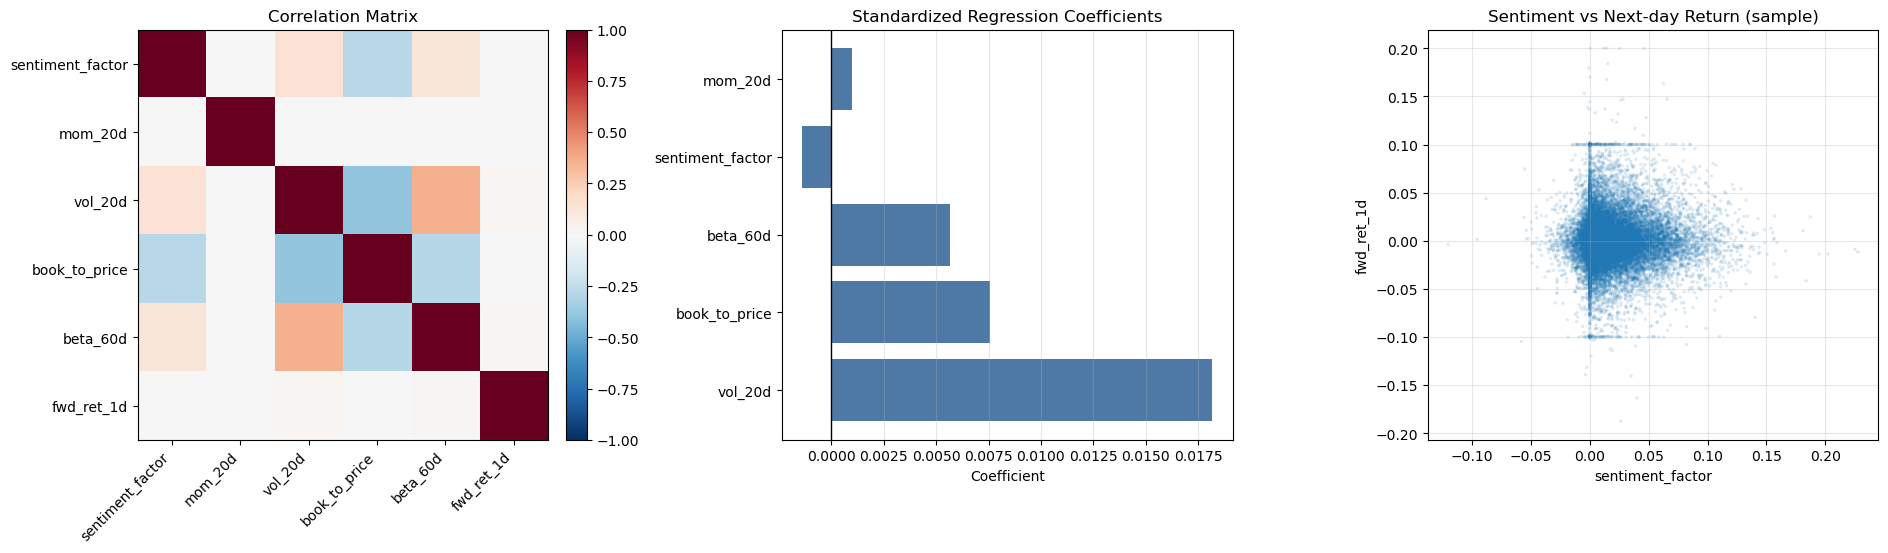


✅ Sentiment-factor regression and correlation analysis complete


In [4]:
# 4.3 Sentiment × Factor Zoo: regression + correlation matrix + visualization
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 72)
print("4.4 SENTIMENT + FACTOR ZOO REGRESSION / CORRELATION")
print("=" * 72)

# ---- 1) Load Factor Zoo from parent folder (preferred) ----
db_candidates = [Path("../factor_zoo.duckdb"), Path("factor_zoo.duckdb")]
factor_db_path = next((p.resolve() for p in db_candidates if p.exists()), None)
if factor_db_path is None:
    raise FileNotFoundError("factor_zoo.duckdb not found in parent/current folder")

# ---- 2) Load sentiment factor (unified only) ----
sent_candidates = [
    Path("sentiment_score_extended_90d_unified.csv"),
    Path("../sentiment_score_extended_90d_unified.csv"),
]
sent_path = next((p.resolve() for p in sent_candidates if p.exists()), None)
if sent_path is None:
    raise FileNotFoundError("sentiment_score_extended_90d_unified.csv not found in current/parent folder")

sent_df = pd.read_csv(sent_path, usecols=["date", "stock", "extended_sentiment_90d"])
sent_df["trade_date"] = pd.to_datetime(sent_df["date"].astype(str), format="%Y%m%d", errors="coerce")
sent_df["stock_code"] = sent_df["stock"].astype(str).str.zfill(6)
sent_df["sentiment_factor"] = pd.to_numeric(sent_df["extended_sentiment_90d"], errors="coerce")
sent_df = sent_df[["trade_date", "stock_code", "sentiment_factor"]].dropna()

print(f"Factor DB: {factor_db_path}")
print(f"Sentiment file: {sent_path}")
print(f"Sentiment rows loaded: {len(sent_df):,}")

# ---- 3) Join sentiment with factor zoo and create forward return ----
con = duckdb.connect(str(factor_db_path), read_only=True)
con.register("sentiment_df", sent_df)

sql = """
WITH fac AS (
    SELECT
        trade_date,
        stock_code,
        ret_1d,
        LEAD(ret_1d) OVER (PARTITION BY stock_code ORDER BY trade_date) AS fwd_ret_1d,
        mom_20d,
        vol_20d,
        book_to_price,
        size_ln_mv,
        turnover_mean_20d,
        beta_60d
    FROM factor_zoo_daily
),
joined AS (
    SELECT
        f.trade_date,
        f.stock_code,
        s.sentiment_factor,
        f.fwd_ret_1d,
        f.mom_20d,
        f.vol_20d,
        f.book_to_price,
        f.size_ln_mv,
        f.turnover_mean_20d,
        f.beta_60d
    FROM fac f
    INNER JOIN sentiment_df s
      ON f.trade_date = s.trade_date
     AND f.stock_code = s.stock_code
    WHERE f.fwd_ret_1d IS NOT NULL
      AND f.stock_code <> '000300'
      AND s.sentiment_factor IS NOT NULL
),
sampled AS (
    SELECT *
    FROM joined
    USING SAMPLE 800000 ROWS
 )
SELECT * FROM sampled
"""

factor_reg_df = con.execute(sql).fetchdf()
con.close()

if factor_reg_df.empty:
    raise ValueError("Joined analysis dataframe is empty before regression.")

print(f"Joined rows (before dropna): {len(factor_reg_df):,}")
print(f"Date range: {factor_reg_df['trade_date'].min()} -> {factor_reg_df['trade_date'].max()}")

# ---- 4) Regression analysis (standardized OLS via numpy) ----
candidate_features = [
    "sentiment_factor",
    "mom_20d",
    "vol_20d",
    "book_to_price",
    "size_ln_mv",
    "turnover_mean_20d",
    "beta_60d",
]
target_col = "fwd_ret_1d"

# choose features by non-null coverage
coverage = factor_reg_df[candidate_features].notna().mean().sort_values(ascending=False)
feature_cols = [c for c in candidate_features if coverage[c] >= 0.10]
if "sentiment_factor" not in feature_cols:
    feature_cols = ["sentiment_factor"] + feature_cols

reg_df = factor_reg_df[feature_cols + [target_col]].copy().dropna()
if reg_df.empty or len(feature_cols) < 1:
    raise ValueError("No valid rows/features available for regression after NA handling.")

X = reg_df[feature_cols].astype(float)
y = reg_df[target_col].astype(float)

Xz = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
yz = (y - y.mean()) / (y.std(ddof=0) if y.std(ddof=0) > 0 else np.nan)
reg_df2 = pd.concat([Xz, yz.rename(target_col)], axis=1).dropna()

Xz_clean = reg_df2[feature_cols].values
yz_clean = reg_df2[target_col].values

design = np.column_stack([np.ones(len(Xz_clean)), Xz_clean])
coef = np.linalg.lstsq(design, yz_clean, rcond=None)[0]
pred = design @ coef
resid = yz_clean - pred
r2 = 1 - np.sum(resid ** 2) / np.sum((yz_clean - yz_clean.mean()) ** 2)

coef_df = pd.DataFrame({
    "factor": ["intercept"] + feature_cols,
    "coef": coef,
})
coef_factors = coef_df[coef_df["factor"] != "intercept"].copy().sort_values("coef", key=np.abs, ascending=False)

print("\nFeature non-null coverage:")
print(coverage.to_string(float_format=lambda v: f"{v:.2%}"))
print(f"\nRows used in regression: {len(reg_df2):,}")
print("\nRegression (standardized OLS)")
print(f"R^2: {r2:.6f}")
print(coef_df.to_string(index=False, formatters={"coef": "{:.6f}".format}))

# ---- 5) Correlation matrix ----
corr_cols = feature_cols + [target_col]
corr_matrix = reg_df[corr_cols].corr(method="pearson")
print("\nCorrelation matrix (Pearson):")
print(corr_matrix.to_string(float_format=lambda v: f"{v: .4f}"))

# ---- 6) Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.patch.set_facecolor("white")

# (a) Correlation heatmap
im = axes[0].imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_cols)))
axes[0].set_xticklabels(corr_cols, rotation=45, ha="right")
axes[0].set_yticks(range(len(corr_cols)))
axes[0].set_yticklabels(corr_cols)
axes[0].set_title("Correlation Matrix")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# (b) Standardized coefficients
axes[1].barh(coef_factors["factor"], coef_factors["coef"], color="#4E79A7")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Standardized Regression Coefficients")
axes[1].set_xlabel("Coefficient")
axes[1].grid(axis="x", alpha=0.3)

# (c) Sentiment vs future return (sampled scatter)
scatter_n = min(30000, len(reg_df))
scatter_df = reg_df.sample(n=scatter_n, random_state=42)
axes[2].scatter(scatter_df["sentiment_factor"], scatter_df["fwd_ret_1d"], s=6, alpha=0.15, edgecolors="none")
axes[2].set_title("Sentiment vs Next-day Return (sample)")
axes[2].set_xlabel("sentiment_factor")
axes[2].set_ylabel("fwd_ret_1d")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Sentiment-factor regression and correlation analysis complete")

### Cell 18: Purpose, Formula, and Logic
- **Role**: Compute step: # 4.5 Best Sharpe Portfolio via Mean-Variance Optimization (Rolling 60M L2Boost, with/without sentiment)
- **Algorithm Logic**: Initializes dependencies and runtime objects, then validates required resources before downstream steps.
- **Formula**: $\mathrm{Sharpe}=\frac{\mathbb{E}[r]}{\sigma(r)}\sqrt{252}$, and $\mathrm{NAV}_t=\prod_{i\le t}(1+r_i)$.


4.5 BEST SHARPE PORTFOLIO: ROLLING 60M L2BOOST (WITH/WITHOUT SENTIMENT)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Panel rows: 583,267
Date range: 2017-01-04 00:00:00 -> 2025-12-05 00:00:00

Feature coverage on IS:
sentiment_factor    100.00%
ret_1d_cs_z         100.00%
amihud_20d          100.00%
book_to_price       100.00%
beta_60d             99.98%
vol_60d              99.98%
vol_20d              99.98%
vol_20d_cs_z         99.98%
mom_5d               99.90%
sales_yield          99.59%
mom_20d_cs_z         99.59%
mom_20d              99.59%
mom_60d              98.74%
earnings_yield       97.86%
cashflow_yield        0.00%
turnover_mean_20d     0.00%
size_ln_mv            0.00%
size_cs_z             0.00%

Selected features with sentiment (14): ['sentiment_factor', 'mom_5d', 'mom_20d', 'mom_60d', 'vol_20d', 'vol_60d', 'book_to_price', 'earnings_yield', 'sales_yield', 'beta_60d', 'amihud_20d', 'ret_1d_cs_z', 'mom_20d_cs_z', 'vol_20d_cs_z']
Selected features without sentiment (13): ['mom_5d', 'mom_20d', 'mom_60d', 'vol_20d', 'vol_60d', 'book_to_price', 'earnings_yield', 'sales_yield', 'beta_60d',

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
      

[L2Boost_withSent] tuned params: {'max_iter': 300, 'learning_rate': 0.04, 'max_depth': 3, 'min_samples_leaf': 30, 'l2_regularization': 1e-05}, tune IS Sharpe=8.5952
[L2Boost_noSent] tuned params: {'max_iter': 300, 'learning_rate': 0.04, 'max_depth': 3, 'min_samples_leaf': 30, 'l2_regularization': 1e-05}, tune IS Sharpe=8.7086

Performance Summary (IS vs OOS)
           Model                Sample ann_return ann_vol sharpe max_dd total_return
L2Boost_withSent      In-Sample(<2021)     63.24%   7.25%  8.722 -2.42%      546.82%
L2Boost_withSent Out-of-Sample(>=2021)      8.08%   7.20%  1.122 -7.03%       44.03%
  L2Boost_noSent      In-Sample(<2021)     62.08%   7.16%  8.675 -2.41%      529.42%
  L2Boost_noSent Out-of-Sample(>=2021)      8.60%   7.12%  1.209 -6.94%       47.38%

Sharpe Ratios by Model:
  L2Boost_withSent   IS Sharpe= 8.7221 | OOS Sharpe= 1.1216
  L2Boost_noSent     IS Sharpe= 8.6753 | OOS Sharpe= 1.2086

Saved factor-selection files:
  - factor_selection_outputs\factor_se

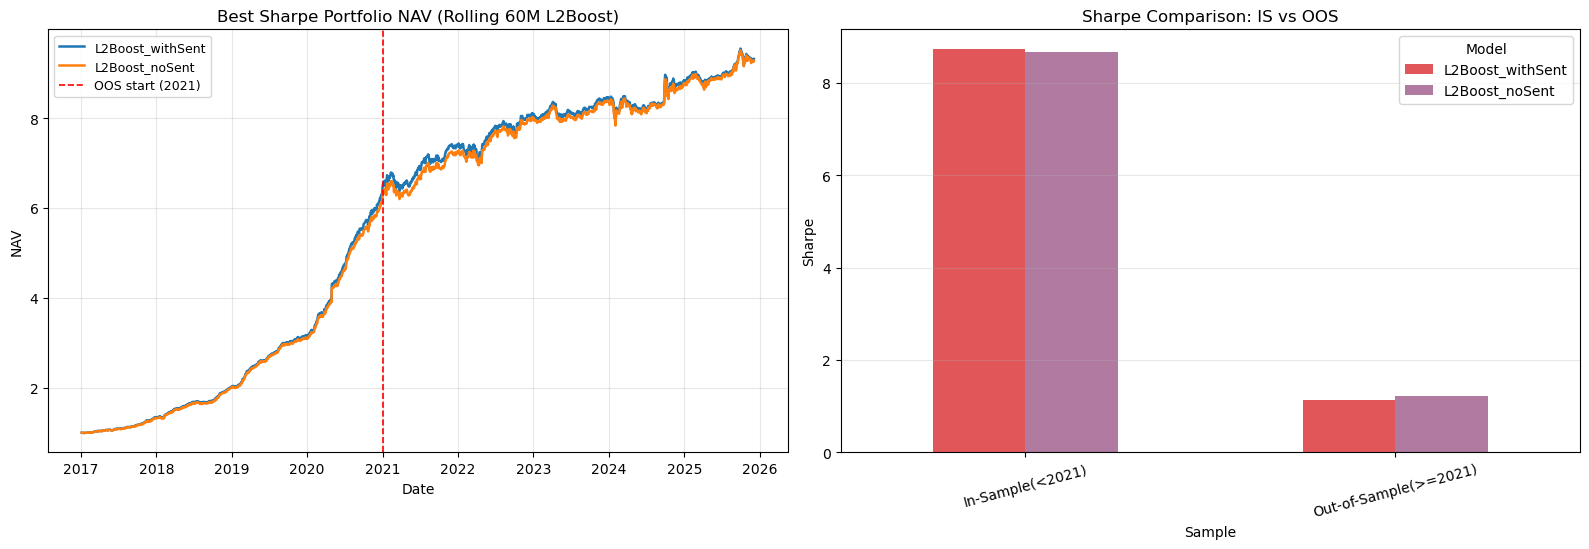


✅ Best Sharpe portfolio backtest complete (OOS>=2021, rolling=60M, L2Boost only)


In [1]:
# 4.5 Best Sharpe Portfolio via Mean-Variance Optimization (Rolling 60M L2Boost, with/without sentiment)
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

print("=" * 92)
print("4.5 BEST SHARPE PORTFOLIO: ROLLING 60M L2BOOST (WITH/WITHOUT SENTIMENT)")
print("=" * 92)

# ---- Global settings ----
OOS_START_YEAR = 2021
ROLLING_MONTHS = 60
MIN_TRAIN_ROWS = 20000
MIN_TRAIN_DATES = 400

# speed controls
TUNE_MAX_DATES = 180
TUNE_MAX_ROWS = 120000
IMPORTANCE_SAMPLE_ROWS = 30000

# ---- 1) Load factor + sentiment panel ----
db_candidates = [Path("../factor_zoo.duckdb"), Path("factor_zoo.duckdb")]
factor_db_path = next((p.resolve() for p in db_candidates if p.exists()), None)
if factor_db_path is None:
    raise FileNotFoundError("factor_zoo.duckdb not found in parent/current folder")

sent_candidates = [
    Path("sentiment_score_extended_90d_unified.csv"),
    Path("../sentiment_score_extended_90d_unified.csv"),
]
sent_path = next((p.resolve() for p in sent_candidates if p.exists()), None)
if sent_path is None:
    raise FileNotFoundError("sentiment_score_extended_90d_unified.csv not found in current/parent folder")

sent_df = pd.read_csv(sent_path, usecols=["date", "stock", "extended_sentiment_90d"])
sent_df["trade_date"] = pd.to_datetime(sent_df["date"].astype(str), format="%Y%m%d", errors="coerce")
sent_df["stock_code"] = sent_df["stock"].astype(str).str.zfill(6)
sent_df["sentiment_factor"] = pd.to_numeric(sent_df["extended_sentiment_90d"], errors="coerce")
sent_df = sent_df[["trade_date", "stock_code", "sentiment_factor"]].dropna()

con = duckdb.connect(str(factor_db_path), read_only=True)
con.register("sentiment_df", sent_df)

panel_sql = """
WITH fac AS (
    SELECT
        trade_date, stock_code,
        ret_1d,
        LEAD(ret_1d) OVER (PARTITION BY stock_code ORDER BY trade_date) AS fwd_ret_1d,
        mom_5d, mom_20d, mom_60d,
        vol_20d, vol_60d,
        book_to_price, earnings_yield, sales_yield, cashflow_yield,
        beta_60d,
        turnover_mean_20d, amihud_20d,
        size_ln_mv,
        ret_1d_cs_z, mom_20d_cs_z, vol_20d_cs_z, size_cs_z
    FROM factor_zoo_daily
),
joined AS (
    SELECT
        f.*,
        s.sentiment_factor
    FROM fac f
    INNER JOIN sentiment_df s
      ON f.trade_date = s.trade_date
     AND f.stock_code = s.stock_code
    WHERE f.stock_code <> '000300'
      AND f.fwd_ret_1d IS NOT NULL
      AND s.sentiment_factor IS NOT NULL
)
SELECT * FROM joined
ORDER BY trade_date, stock_code
"""
panel = con.execute(panel_sql).fetchdf()
con.close()

if panel.empty:
    raise ValueError("Modeling panel is empty.")

panel["trade_date"] = pd.to_datetime(panel["trade_date"], errors="coerce")
panel = panel.dropna(subset=["trade_date", "fwd_ret_1d", "stock_code"]).copy()
panel["year"] = panel["trade_date"].dt.year
panel["month"] = panel["trade_date"].dt.to_period("M")

print(f"Panel rows: {len(panel):,}")
print(f"Date range: {panel['trade_date'].min()} -> {panel['trade_date'].max()}")

# ---- 2) Split and features ----
is_mask = panel["year"] < OOS_START_YEAR
oos_mask = panel["year"] >= OOS_START_YEAR
if is_mask.sum() == 0 or oos_mask.sum() == 0:
    raise ValueError(f"IS/OOS split failed. Need IS (<{OOS_START_YEAR}) and OOS (>={OOS_START_YEAR}) samples.")

candidate_features = [
    "sentiment_factor",
    "mom_5d", "mom_20d", "mom_60d",
    "vol_20d", "vol_60d",
    "book_to_price", "earnings_yield", "sales_yield", "cashflow_yield",
    "beta_60d",
    "turnover_mean_20d", "amihud_20d",
    "size_ln_mv",
    "ret_1d_cs_z", "mom_20d_cs_z", "vol_20d_cs_z", "size_cs_z",
]

coverage_is = panel.loc[is_mask, candidate_features].notna().mean().sort_values(ascending=False)
feature_cols_with_sent = [c for c in candidate_features if coverage_is[c] >= 0.10]
if "sentiment_factor" not in feature_cols_with_sent:
    feature_cols_with_sent = ["sentiment_factor"] + feature_cols_with_sent
feature_cols_no_sent = [c for c in feature_cols_with_sent if c != "sentiment_factor"]
if len(feature_cols_no_sent) == 0:
    raise ValueError("No non-sentiment features available for control model.")

print("\nFeature coverage on IS:")
print(coverage_is.to_string(float_format=lambda v: f"{v:.2%}"))
print(f"\nSelected features with sentiment ({len(feature_cols_with_sent)}): {feature_cols_with_sent}")
print(f"Selected features without sentiment ({len(feature_cols_no_sent)}): {feature_cols_no_sent}")

# ---- 3) Backtest helpers ----
def build_strategy_returns_fast(df: pd.DataFrame, pred_col: str, l2_ridge: float = 1e-6) -> pd.DataFrame:
    d = df[["trade_date", pred_col, "fwd_ret_1d", "risk_vol"]].dropna().copy()
    if d.empty:
        return pd.DataFrame(columns=["trade_date", "ret", "nav", "year"])

    d["risk_vol"] = pd.to_numeric(d["risk_vol"], errors="coerce").clip(lower=1e-4)
    d = d.dropna(subset=["risk_vol"])

    by_date = d.groupby("trade_date")
    date_count = by_date[pred_col].transform("size")
    d = d[date_count >= 20].copy()
    if d.empty:
        return pd.DataFrame(columns=["trade_date", "ret", "nav", "year"])

    by_date = d.groupby("trade_date")
    mu_mean = by_date[pred_col].transform("mean")
    mu_std = by_date[pred_col].transform("std").replace(0.0, np.nan)
    d["mu"] = ((d[pred_col] - mu_mean) / mu_std).fillna(d[pred_col] - mu_mean).clip(-3.0, 3.0)

    d["inv_var"] = 1.0 / (np.square(d["risk_vol"].values) + l2_ridge)
    d["w_raw"] = d["mu"] * d["inv_var"]
    d["w_raw"] = d["w_raw"] - d.groupby("trade_date")["w_raw"].transform("mean")

    gross = d.groupby("trade_date")["w_raw"].transform(lambda s: np.abs(s).sum())
    d["w"] = np.where(gross > 1e-12, d["w_raw"] / gross, 0.0)

    d["wr"] = d["w"].values * d["fwd_ret_1d"].values
    daily_ret = d.groupby("trade_date", as_index=False)["wr"].sum().rename(columns={"wr": "ret"})
    daily_ret["ret"] = pd.to_numeric(daily_ret["ret"], errors="coerce").fillna(0.0)
    daily_ret["nav"] = (1.0 + daily_ret["ret"]).cumprod()
    daily_ret["year"] = daily_ret["trade_date"].dt.year
    return daily_ret

def perf_stats(ret_series: pd.Series) -> dict:
    r = pd.Series(ret_series).dropna()
    if len(r) == 0:
        return {"ann_return": np.nan, "ann_vol": np.nan, "sharpe": np.nan, "max_dd": np.nan, "total_return": np.nan}
    nav = (1.0 + r).cumprod()
    ann_return = nav.iloc[-1] ** (252 / len(r)) - 1
    ann_vol = r.std(ddof=0) * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan
    max_dd = (nav / nav.cummax() - 1.0).min()
    total_return = nav.iloc[-1] - 1.0
    return {
        "ann_return": float(ann_return),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,
        "max_dd": float(max_dd),
        "total_return": float(total_return),
    }

def split_metrics(daily_df: pd.DataFrame, model_name: str) -> list:
    ins = daily_df[daily_df["year"] < OOS_START_YEAR]["ret"]
    oos = daily_df[daily_df["year"] >= OOS_START_YEAR]["ret"]
    return [
        {"Model": model_name, "Sample": f"In-Sample(<{OOS_START_YEAR})", **perf_stats(ins)},
        {"Model": model_name, "Sample": f"Out-of-Sample(>={OOS_START_YEAR})", **perf_stats(oos)},
    ]

def zscore_by_date(series: pd.Series, dates: pd.Series) -> pd.Series:
    temp = pd.DataFrame({"date": dates.values, "v": series.values})
    g = temp.groupby("date")["v"]
    mean = g.transform("mean")
    std = g.transform("std").replace(0.0, np.nan)
    z = ((temp["v"] - mean) / (std + 1e-8)).clip(-3.0, 3.0)
    return z.fillna(0.0)

def is_sharpe_for_pred(tmp_df: pd.DataFrame) -> float:
    ret_df = build_strategy_returns_fast(tmp_df[["trade_date", "fwd_ret_1d", "risk_vol", "pred"]], "pred")
    return perf_stats(ret_df["ret"])["sharpe"]

def make_l2boost(params: dict) -> HistGradientBoostingRegressor:
    return HistGradientBoostingRegressor(
        loss="squared_error",
        max_iter=params["max_iter"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        l2_regularization=params["l2_regularization"],
        random_state=42,
        early_stopping=False,
    )

# ---- 4) L2Boost model runner (rolling 60 months) ----
def run_l2boost_variant(model_name: str, feature_cols: list) -> dict:
    base_cols = ["trade_date", "stock_code", "fwd_ret_1d", "vol_60d", "year", "month"]
    all_cols = list(dict.fromkeys(base_cols + feature_cols))
    model_df = panel[all_cols].copy()

    # preprocess features
    is_medians = model_df.loc[is_mask, feature_cols].median()
    for col in feature_cols:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(is_medians[col])

    model_df["risk_vol"] = pd.to_numeric(model_df["vol_60d"], errors="coerce")
    rv_med = model_df.loc[is_mask, "risk_vol"].median()
    if pd.isna(rv_med) or rv_med <= 0:
        rv_med = 0.03
    model_df["risk_vol"] = model_df["risk_vol"].fillna(rv_med).clip(lower=1e-4)

    # hyperparameter tuning on IS (one-time)
    param_grid = [
        {"max_iter": 220, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 40, "l2_regularization": 1e-5},
        {"max_iter": 300, "learning_rate": 0.04, "max_depth": 3, "min_samples_leaf": 30, "l2_regularization": 1e-5},
    ]

    X_is_full = model_df.loc[is_mask, feature_cols].values
    y_is = model_df.loc[is_mask, "fwd_ret_1d"].values

    y_mean = float(np.mean(y_is))
    y_std = float(np.std(y_is))
    if y_std <= 1e-12:
        y_std = 1.0
    y_is_z = (y_is - y_mean) / y_std

    tune_dates = model_df.loc[is_mask, "trade_date"].drop_duplicates().sort_values()
    if len(tune_dates) > TUNE_MAX_DATES:
        idx = np.linspace(0, len(tune_dates) - 1, TUNE_MAX_DATES).astype(int)
        tune_dates = set(tune_dates.iloc[idx].tolist())
    else:
        tune_dates = set(tune_dates.tolist())

    # row sampling for faster parameter search
    n_is = len(X_is_full)
    if n_is > TUNE_MAX_ROWS:
        rng = np.random.default_rng(42)
        sample_idx = np.sort(rng.choice(n_is, size=TUNE_MAX_ROWS, replace=False))
        X_is_tune = X_is_full[sample_idx]
        y_is_tune = y_is_z[sample_idx]
    else:
        X_is_tune = X_is_full
        y_is_tune = y_is_z

    best = {"sharpe": -np.inf, "params": None}
    model_df_is = model_df.loc[is_mask, ["trade_date", "fwd_ret_1d", "risk_vol"]].copy()

    for p in param_grid:
        mdl = make_l2boost(p)
        mdl.fit(X_is_tune, y_is_tune)
        pred_is = mdl.predict(X_is_full) * y_std + y_mean

        tmp = model_df_is.copy()
        tmp["pred"] = zscore_by_date(pd.Series(pred_is), tmp["trade_date"])
        tmp = tmp[tmp["trade_date"].isin(tune_dates)]
        s = is_sharpe_for_pred(tmp)
        if pd.notna(s) and s > best["sharpe"]:
            best = {"sharpe": float(s), "params": p}

    best_params = best["params"]
    print(f"[{model_name}] tuned params: {best_params}, tune IS Sharpe={best['sharpe']:.4f}")

    # predictions container
    model_df["raw_pred"] = np.nan

    # IS prediction: one model fit on all IS
    mdl_is = make_l2boost(best_params)
    mdl_is.fit(X_is_full, y_is_z)
    model_df.loc[is_mask, "raw_pred"] = mdl_is.predict(X_is_full) * y_std + y_mean

    # OOS prediction: rolling 60-month monthly retrain
    oos_months = sorted(model_df.loc[oos_mask, "month"].drop_duplicates())

    for mon in oos_months:
        pred_mask = (model_df["month"] == mon) & oos_mask
        month_start = model_df.loc[pred_mask, "trade_date"].min()

        train_end = month_start - pd.Timedelta(days=1)
        train_start = train_end - pd.DateOffset(months=ROLLING_MONTHS) + pd.Timedelta(days=1)

        train_mask = (model_df["trade_date"] >= train_start) & (model_df["trade_date"] <= train_end)
        train_rows = int(train_mask.sum())
        train_dates = int(model_df.loc[train_mask, "trade_date"].nunique())

        if train_rows < MIN_TRAIN_ROWS or train_dates < MIN_TRAIN_DATES:
            fallback_mask = is_mask & (model_df["trade_date"] <= train_end)
            if fallback_mask.sum() > train_mask.sum():
                train_mask = fallback_mask

        if train_mask.sum() == 0 or pred_mask.sum() == 0:
            continue

        X_train = model_df.loc[train_mask, feature_cols].values
        y_train = model_df.loc[train_mask, "fwd_ret_1d"].values

        y_tr_mean = float(np.mean(y_train))
        y_tr_std = float(np.std(y_train))
        if y_tr_std <= 1e-12:
            y_tr_std = 1.0
        y_train_z = (y_train - y_tr_mean) / y_tr_std

        X_pred = model_df.loc[pred_mask, feature_cols].values

        mdl = make_l2boost(best_params)
        mdl.fit(X_train, y_train_z)
        model_df.loc[pred_mask, "raw_pred"] = mdl.predict(X_pred) * y_tr_std + y_tr_mean

    model_df["raw_pred"] = model_df["raw_pred"].fillna(0.0)
    model_df["pred"] = zscore_by_date(model_df["raw_pred"], model_df["trade_date"])

    daily_ret = build_strategy_returns_fast(model_df[["trade_date", "fwd_ret_1d", "risk_vol", "pred"]], "pred")

    # importance via permutation on IS sample (HistGB has no feature_importances_)
    n_imp = len(X_is_full)
    if n_imp > IMPORTANCE_SAMPLE_ROWS:
        rng_imp = np.random.default_rng(7)
        idx_imp = np.sort(rng_imp.choice(n_imp, size=IMPORTANCE_SAMPLE_ROWS, replace=False))
        X_imp = X_is_full[idx_imp]
        y_imp = y_is_z[idx_imp]
    else:
        X_imp = X_is_full
        y_imp = y_is_z

    perm = permutation_importance(
        mdl_is,
        X_imp,
        y_imp,
        scoring="neg_mean_squared_error",
        n_repeats=3,
        random_state=42,
    )
    mean_imp = perm.importances_mean

    factors = pd.DataFrame({"factor": feature_cols, "rolling_mean_importance": mean_imp})
    factors = factors.sort_values("rolling_mean_importance", ascending=False)
    for k, v in best_params.items():
        factors[f"best_{k}"] = v
    factors["rolling_months"] = ROLLING_MONTHS
    factors["tune_is_sharpe"] = best["sharpe"]

    return {
        "model_name": model_name,
        "returns": daily_ret,
        "factors": factors,
    }

# ---- 5) Run only L2Boost variants (with/without sentiment) ----
variant_specs = [
    {"model_name": "L2Boost_withSent", "features": feature_cols_with_sent},
    {"model_name": "L2Boost_noSent", "features": feature_cols_no_sent},
]

variant_results = {}
metrics_rows = []
for spec in variant_specs:
    out = run_l2boost_variant(spec["model_name"], spec["features"])
    variant_results[spec["model_name"]] = out
    metrics_rows.extend(split_metrics(out["returns"], spec["model_name"]))

metrics_df = pd.DataFrame(metrics_rows)

print("\nPerformance Summary (IS vs OOS)")
print(metrics_df.to_string(index=False, formatters={
    "ann_return": "{:.2%}".format,
    "ann_vol": "{:.2%}".format,
    "sharpe": "{:.3f}".format,
    "max_dd": "{:.2%}".format,
    "total_return": "{:.2%}".format,
}))

print("\nSharpe Ratios by Model:")
for model_name in [s["model_name"] for s in variant_specs]:
    is_row = metrics_df[(metrics_df["Model"] == model_name) & (metrics_df["Sample"] == f"In-Sample(<{OOS_START_YEAR})")]
    oos_row = metrics_df[(metrics_df["Model"] == model_name) & (metrics_df["Sample"] == f"Out-of-Sample(>={OOS_START_YEAR})")]
    is_sharpe = float(is_row["sharpe"].iloc[0]) if not is_row.empty else np.nan
    oos_sharpe = float(oos_row["sharpe"].iloc[0]) if not oos_row.empty else np.nan
    print(f"  {model_name:<18} IS Sharpe={is_sharpe: .4f} | OOS Sharpe={oos_sharpe: .4f}")

# ---- 6) Save outputs ----
factor_out_dir = Path("factor_selection_outputs")
factor_out_dir.mkdir(parents=True, exist_ok=True)

saved_files = []
for model_name, out in variant_results.items():
    factor_df = out["factors"].copy()
    factor_df.insert(0, "model", model_name)
    factor_df.insert(1, "oos_start_year", OOS_START_YEAR)
    factor_df.insert(2, "has_sentiment", "withSent" in model_name)

    out_file = factor_out_dir / f"factor_selection_{model_name}.csv"
    factor_df.to_csv(out_file, index=False, encoding="utf-8-sig")
    saved_files.append(out_file)

metrics_file = factor_out_dir / "best_sharpe_metrics_with_without_sentiment.csv"
metrics_df.to_csv(metrics_file, index=False, encoding="utf-8-sig")
saved_files.append(metrics_file)

print("\nSaved factor-selection files:")
for p in saved_files:
    print(f"  - {p}")

for model_name, out in variant_results.items():
    print(f"\n{model_name} selected factors:")
    print(out["factors"].to_string(index=False))

# ---- 7) Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5.6))
fig.patch.set_facecolor("white")

plot_order = ["L2Boost_withSent", "L2Boost_noSent"]
for name in plot_order:
    df_plot = variant_results[name]["returns"]
    axes[0].plot(df_plot["trade_date"], df_plot["nav"], label=name, linewidth=1.8)

axes[0].axvline(pd.Timestamp(f"{OOS_START_YEAR}-01-01"), color="red", linestyle="--", linewidth=1.2, label=f"OOS start ({OOS_START_YEAR})")
axes[0].set_title(f"Best Sharpe Portfolio NAV (Rolling {ROLLING_MONTHS}M L2Boost)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("NAV")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

pivot_sharpe = metrics_df.pivot(index="Sample", columns="Model", values="sharpe")
pivot_sharpe = pivot_sharpe.reindex(columns=plot_order)
pivot_sharpe.plot(kind="bar", ax=axes[1], color=["#E15759", "#B07AA1"])
axes[1].set_title("Sharpe Comparison: IS vs OOS")
axes[1].set_ylabel("Sharpe")
axes[1].grid(alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

best_sharpe_results = {
    "oos_start_year": OOS_START_YEAR,
    "rolling_months": ROLLING_MONTHS,
    "metrics": metrics_df,
    "variant_returns": {k: v["returns"] for k, v in variant_results.items()},
    "variant_factors": {k: v["factors"] for k, v in variant_results.items()},
    "feature_cols_with_sent": feature_cols_with_sent,
    "feature_cols_no_sent": feature_cols_no_sent,
    "factor_output_dir": str(factor_out_dir),
}

print(f"\n✅ Best Sharpe portfolio backtest complete (OOS>={OOS_START_YEAR}, rolling={ROLLING_MONTHS}M, L2Boost only)")